## 1.1 Install Dependencies & Imports

In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "nltk", "scikit-learn", "numpy", "pandas",
                       "matplotlib", "seaborn", "flask", "flask-cors"])

import nltk
for pkg in ["punkt","punkt_tab","wordnet","stopwords","omw-1.4"]:
    nltk.download(pkg, quiet=True)

import json, re, random, pickle, os
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import (train_test_split, learning_curve,
                                     cross_val_score, StratifiedKFold)
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, log_loss)

# Global plot style
sns.set_theme(style="whitegrid", palette="muted", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "axes.titlesize": 13,
    "axes.labelsize": 11, "xtick.labelsize": 9, "ytick.labelsize": 9,
})
COLORS = {
    "rule":"#27AE60","nb":"#2E86AB","fallback":"#F39C12",
    "correct":"#2ECC71","wrong":"#E74C3C","neutral":"#95A5A6"
}
print("Iteration 1 Environment ready")

Iteration 1 Environment ready


## 1.2 Load Dataset

In [2]:
def load_intents(filepath="intents_final.json"):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    print(f"Loaded {len(data['intents'])} intents from '{filepath}'")
    return data

intents_data = load_intents("intents_final.json")

Loaded 90 intents from 'intents_final.json'


### Iteration 1 - Visualization 1: Dataset Overview

In [3]:
lemmatizer = WordNetLemmatizer()
try:
    STOPWORDS = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords"); STOPWORDS = set(stopwords.words("english"))

IMPORTANT_WORDS = {"not","no","when","where","how","what","who",
                   "which","why","can","is","are","have","do",
                   "does","will","any","more"}
STOPWORDS -= IMPORTANT_WORDS

ROMAN_NEPALI_MAP = {
    "k xa bro":"what is","k ho bro":"what is","kaha xa bro":"where is",
    "kaha cha":"where is","kaha xa":"where is","kati xa":"how much",
    "kati ho":"how much","kati cha":"how much","kasari garne":"how to do",
    "kasari linu":"how to get","kasari":"how","kun kun":"which all",
    "kun":"which","k xa":"what is","k ho":"what is","k chha":"what is",
    "k cha":"what is","kasto":"what kind","kahile":"when",
    "paincha ki":"available","paincha":"available get",
    "milcha ki":"possible","milcha":"possible available",
    "lagcha":"cost required","huncha":"happens",
    "padhna xa":"want to study","padhna":"study","padhye":"after studying",
    "garne":"do","garnu":"do","linu":"take","dinu":"give",
    "hernu":"check see","apply garne":"apply","join garne":"join",
    "bata":"from","ramro xa":"good","ramro":"good","sasto":"cheap affordable",
    "mahango":"expensive","ekdam":"very","dherai":"very much",
    "thik xa":"okay","namaste":"hello","namaskar":"hello",
    "sanchai":"hello","dhanyabad":"thank you","shukriya":"thank you",
    "kaam lagyo":"helpful","clear bhayo":"clear understood",
    "bujhyo":"understood",
    "bro":"","dai":"","didi":"","yar":"","ni":"","na":"",
    "ta":"","nai":"","hai":"","aba":"","ra":"",
}

# r=raw string
# \bbit\b sets boundary for bit 

ABBR_MAP = {
    r"\bbit\b":"bachelor information technology",
    r"\bbca\b":"bachelor computer application",
    r"\bbba\b":"bachelor business administration",
    r"\bbhm\b":"bachelor hospitality management",
    r"\btu\b":"tribhuvan university",
    r"\bfyp\b":"final year project",
    r"\bgpa\b":"grade point average",
    r"\bit\b":"information technology",
    r"\bcs\b":"computer science",
    r"\bai\b":"artificial intelligence",
    r"\bml\b":"machine learning",
    r"\bapi\b":"application programming interface",
}

CONTRACTIONS = {
    r"what's":"what is",r"don't":"do not",r"doesn't":"does not",
    r"can't":"cannot",r"won't":"will not",r"isn't":"is not",
    r"aren't":"are not",r"i'm":"i am",r"you're":"you are",
    r"it's":"it is",r"we're":"we are",r"they're":"they are",
    r"i've":"i have",r"you've":"you have",r"i'll":"i will",
    r"you'll":"you will",r"he's":"he is",r"she's":"she is",
}

# Normal function:
# def get_length(x):
#     return len(x[0])

# Same thing as lambda:
# lambda x: len(x[0])
# accepts any iterables (list, tuple, dict, string) and returns a new shorted list.
# The minus sign makes sorted() go from largest to smallest (longest phrase first).


# re.sub(pattern, replacement, text)
# re.sub("bro", "", "fees bro kati")
# Result: "fees  kati"
# Found "bro", replaced with "" (deleted it)
# re.escape() makes sure special characters in the key are treated as plain text, not regex commands.


def normalize_fb_nepali(text):
    for k,v in sorted(ROMAN_NEPALI_MAP.items(), key=lambda x:-len(x[0])):
        text = re.sub(r'\b'+re.escape(k)+r'\b', v, text)
    return text

def expand_abbreviations(text):
    for p,r in ABBR_MAP.items():
        text = re.sub(p, r, text, flags=re.IGNORECASE)
    return text

# isinstance() checks what type/category a variable is.
# isinstance(variable, type)
    
# .lower() → converts everything to lowercase
# "BCA FEES KATI HO" → "bca fees kati ho"
# .strip() → removes spaces from start and end
# "  bca fees  " → "bca fees"
# Both together:
# "  BCA FEES KATI HO  " → "bca fees kati ho"
    

def clean_text(text):
    if not text or not isinstance(text,str): return ""
    text = text.lower().strip()
    for c,e in CONTRACTIONS.items():
        text = re.sub(c, e, text, flags=re.IGNORECASE)
    text = re.sub(r'https?://\S+|www\.\S+|[\w\.-]+@[\w\.-]+\.\w+','',text)
    text = normalize_fb_nepali(text)
    text = expand_abbreviations(text)
    text = re.sub(r"[^a-zA-Z\s']"," ",text)
    text = re.sub(r"\s+"," ",text).strip()
    return text

# re.sub(r"\s+", " ", text)
# \s+ = one or more spaces/tabs → replace all with single space
# "fees   kati    ho" → "fees kati ho"
# "bca  admission"    → "bca admission"

# .strip() → remove leading/trailing spaces
# " bca admission " → "bca admission"
    
def tokenize_and_lemmatize(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t)>1]
    tokens = [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]
    return " ".join(tokens) # Converts list back to a single string
    
    # v,n = verb and noun respectively
#     "studying fees"
# → verb pass  : "study fees"    ("studying"→"study", "fees" unchanged)
# → noun pass  : "study fee"     ("study" unchanged, "fees"→"fee")
# Final: "study fee" ✓

# Same as:
# new_tokens = []
# for t in tokens:
#     if t not in STOPWORDS and len(t) > 1:
#         new_tokens.append(t)

    

def preprocess(text):
    cleaned = clean_text(text)
    final   = tokenize_and_lemmatize(cleaned)
    return final if final.strip() else cleaned

#     clean_text("bro dai")         → "  "  (both words deleted by Nepali map)
# tokenize_and_lemmatize("  ")  → ""    (nothing left after split)

# final.strip() = ""  → empty! → return cleaned instead
# → returns "  " (at least not crashing)

print("Iteration 1 - Preprocessing pipeline loaded")

Iteration 1 - Preprocessing pipeline loaded


### Iteration 1 - Visualization 2: Preprocessing Before vs After

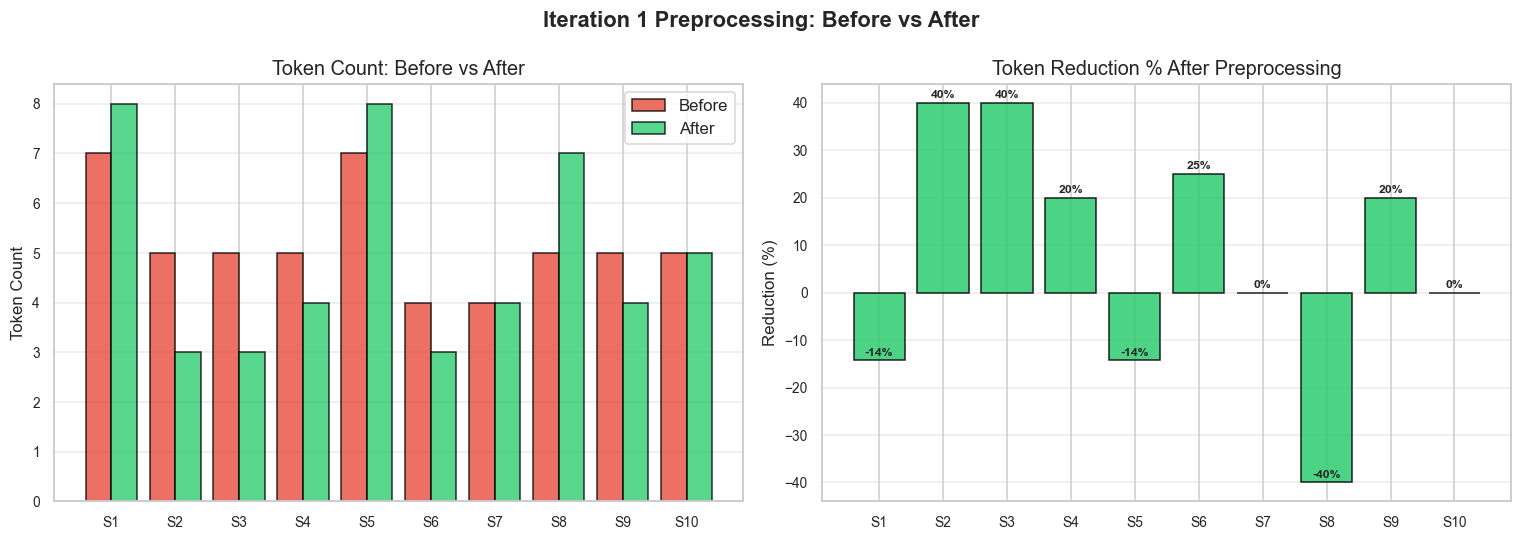


Iteration 1 Complete - Foundation ready for Iteration 2


In [4]:
DEMO_SAMPLES = [
    "BCA padhna xa bro, fees kati ho?",
    "Scholarship paincha ki padmashree ma?",
    "HOW TO APPLY FOR ADMISSION???",
    "kaha xa padmashree college dai",
    "bit course ko scope k xa bro",
    "is there hostel facility??",
    "What's the contact number?",
    "don't know about BIT scope",
    "kasari linu admission form bro",
    "AIML course xa ki chaina?",
]

# Build dataframe
pre_df = pd.DataFrame([{
    "Raw Input": s,
    "After Clean": clean_text(s),
    "Final (Lemmatized)": preprocess(s),
    "Raw Tokens": len(s.split()),
    "Final Tokens": len(preprocess(s).split()),
} for s in DEMO_SAMPLES])

# Token reduction %
labels = [f"S{i+1}" for i in range(len(DEMO_SAMPLES))]
reductions = [(b-a)/b*100 if b>0 else 0
              for b,a in zip(pre_df["Raw Tokens"], pre_df["Final Tokens"])]
bar_colors = [COLORS["correct"] if r<50 else COLORS["fallback"] if r<80 else COLORS["wrong"]
              for r in reductions]

# What is zip()?
# Pairs two lists together element by element:
# zip([7, 4, 5], [6, 3, 4])
# gives pairs: (7,6), (4,3), (5,4)
# b=raw tokens, a=final tokens

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(DEMO_SAMPLES))

# Chart 1 - before vs after
ax1.bar([i-0.2 for i in x], pre_df["Raw Tokens"],   0.4, label="Before", color=COLORS["wrong"],  alpha=0.8, edgecolor="black")
ax1.bar([i+0.2 for i in x], pre_df["Final Tokens"], 0.4, label="After",  color=COLORS["correct"], alpha=0.8, edgecolor="black")
ax1.set(xticks=list(x), xticklabels=labels, title="Token Count: Before vs After", ylabel="Token Count")
ax1.legend(); ax1.grid(axis="y", alpha=0.4)

# Chart 2 - reduction %
ax2.bar(list(x), reductions, color=bar_colors, edgecolor="black", alpha=0.85)
ax2.set(xticks=list(x), xticklabels=labels, title="Token Reduction % After Preprocessing", ylabel="Reduction (%)")
ax2.grid(axis="y", alpha=0.4)
[ax2.text(i, r+1, f"{r:.0f}%", ha="center", fontsize=8, fontweight="bold") for i,r in enumerate(reductions)]

plt.suptitle("Iteration 1 Preprocessing: Before vs After", fontweight="bold")
plt.tight_layout(); plt.show()

print("\nIteration 1 Complete - Foundation ready for Iteration 2")

#  Iteration 2 - Core System Build: Rule-Based + Naive Bayes + Hybrid Engine

## 2.1 Rule-Based Engine (Layer 1)

In [5]:
RULES = [
   
    {
        "pattern": r"\b(md\b|managing\s*director|vice\s*principal"
                   r"|vp\b|chairman"               
                   r"|director\s*number|md\s*contact"
                   r"|head\s*of\s*college|college\s*director"
                   r"|director\s*padmashree|padmashree\s*md)\b",
        "tag": "VP_director",
        "response": None
    },

   
    {
        "pattern": r"(\+977|4112252|4112403"
                   r"|phone\s*number|contact\s*number"
                   r"|helpline|call\s*college|college\s*number"
                   r"|college\s*phone|reach\s*us)",
        "tag": "contact",
        "response": " Phone: +977-1-4112252 / +977-1-4112403\n www.padmashreecollege.edu.np"
    },


    {
        "pattern": r"(gpo\s*box|google\s*map"
                   r"|how\s*to\s*reach\s*college"
                   r"|how\s*to\s*go\s*to\s*college"
                   r"|college\s*address|address\s*of\s*padmashree"
                   r"|where\s*is\s*padmashree\s*college"
                   r"|college\s*location|direction\s*to\s*college)",
        "tag": "location",
        "response": " Padmashree College, Tinkune, Kathmandu, Nepal. (GPO Box: 15252)"
    },


    {
        "pattern": r"(padmashreecollege\.edu\.np"
                   r"|official\s*website|college\s*website"
                   r"|web\s*portal|website\s*link|college\s*site"
                   r"|online\s*portal)",
        "tag": "website",
        "response": " Official website: www.padmashreecollege.edu.np"
    },

 
    {
        "pattern": r"\b(ragging|anti.?ragging"
                   r"|zero\s*tolerance"
                   r"|fresher\s*safe|is\s*college\s*safe"
                   r"|bullying|harassment\s*college"
                   r"|eve\s*teasing)\b",
        "tag": "ragging",
        "response": " Padmashree has ZERO TOLERANCE against ragging."
    },


    {
        "pattern": r"^(hi|hello|hey|yo|namaste|namaskar|sanchai"
                   r"|good\s*morning|good\s*afternoon|good\s*evening"
                   r"|howdy|greetings|sup)[!\s?]*$",  
        "tag": "greeting",
        "response": "Hello! Welcome to Padmashree College. How can I help you?"
    },
    
 
    {
        "pattern": r"\b(bye|goodbye|cya|see\s*you|take\s*care"
                   r"|ok\s*bye|baii|later|good\s*night"
                   r"|farewell|tata)\b",   
        "tag": "goodbye",
        "response": "Goodbye! Best of luck! "
    },
    

    {
        "pattern": r"\b(thank\s*you|thanks|dhanyabad|shukriya"
                   r"|thnx|thx|that\s*helped"
                   r"|appreciate|much\s*appreciated)\b",
        "tag": "thanks",
        "response": "You're welcome! Feel free to ask anything "
    },

   
    {
        "pattern": r"\b(office\s*timing|office\s*timings|office\s*hours"
                   r"|opening\s*time|closing\s*time|college\s*hours"
                   r"|when\s*open|office\s*open|working\s*hours"
                   r"|what\s*time\s*open|college\s*timing"
                   r"|what\s*are\s*the\s*timings|timings\b)\b",
        "tag": "hours",
        "response": None
    },

 
    {
        "pattern": r"\b(all\s*courses|courses\s*available|courses\s*offered"
                   r"|all\s*programs|programs\s*available|programs\s*offered"
                   r"|what\s*courses|which\s*courses|list\s*of\s*courses"
                   r"|list\s*of\s*programs|what\s*programs)\b",
        "tag": "programs_offered",
        "response": None
    },

 
    {
        "pattern": r"\b(fee\s*structure|semester\s*fee|total\s*fee"
                   r"|annual\s*fee|fees\s*kati|how\s*much\s*fee"
                   r"|tuition\s*fee|fees\s*details"
                   r"|fees\s*information|yearly\s*fees)\b",
        "tag": "fees",
        "response": None
    },


    {
        "pattern": r"\b(how\s*to\s*apply|admission\s*process"
                   r"|admission\s*open|enrollment\s*process"
                   r"|how\s*to\s*enroll|get\s*admission"
                   r"|admission\s*procedure|intake\s*open"
                   r"|how\s*can\s*i\s*apply|apply\s*to\s*padmashree)\b",  # ← just add here
        "tag": "admission",
        "response": None
    },
]

def rule_based_match(user_input, intents_data):
    text_lower = user_input.lower().strip()
    for rule in RULES:
        if re.search(rule["pattern"], text_lower, re.IGNORECASE):
            tag = rule["tag"]
            if rule["response"]:
                return tag, rule["response"]
            for intent in intents_data["intents"]:
                if intent["tag"] == tag and intent.get("responses"):
                    return tag, random.choice(intent["responses"])
    return None, None

print(f" Rule-based engine loaded ({len(RULES)} rules)")

 Rule-based engine loaded (12 rules)


### Iteration 2 - Visualization 3: Rule Coverage Analysis

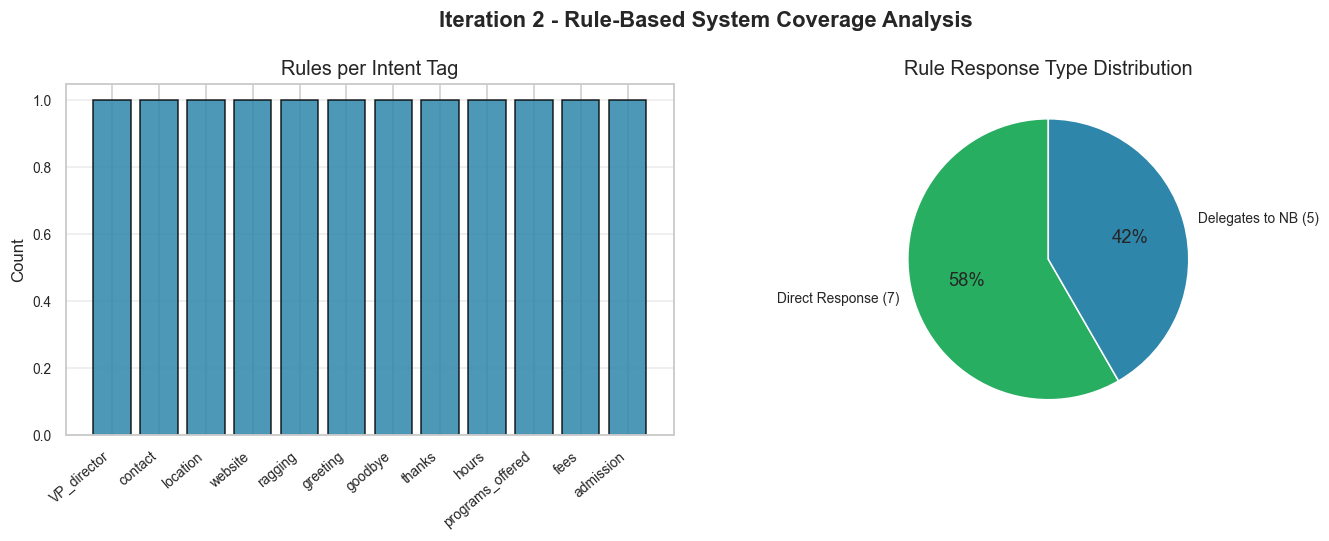

Rules: 12 | Direct: 7 | Delegates: 5


In [6]:
rule_tags  = [r["tag"] for r in RULES]
rule_types = ["Direct" if r["response"] else "Delegates to NB" for r in RULES]
tag_counts = Counter(rule_tags)
tags_sorted = sorted(tag_counts, key=tag_counts.get, reverse=True)

direct   = rule_types.count("Direct")
delegate = rule_types.count("Delegates to NB")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1 - rules per tag
ax1.bar(range(len(tags_sorted)), [tag_counts[t] for t in tags_sorted],
        color=COLORS["nb"], edgecolor="black", alpha=0.85)
ax1.set_xticks(range(len(tags_sorted)))                       
ax1.set_xticklabels(tags_sorted, rotation=40, ha="right")
ax1.set(title="Rules per Intent Tag", ylabel="Count")
ax1.grid(axis="y", alpha=0.4)

# Chart 2 - pie chart
ax2.pie([direct, delegate],
        labels=[f"Direct Response ({direct})", f"Delegates to NB ({delegate})"],
        autopct="%1.0f%%",
        colors=[COLORS["rule"], COLORS["nb"]], startangle=90)
ax2.set_title("Rule Response Type Distribution")

plt.suptitle("Iteration 2 - Rule-Based System Coverage Analysis", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Rules: {len(RULES)} | Direct: {direct} | Delegates: {delegate}")

### Iteration 2 - Visualization 4: Class Distribution

Min: 142 | Max: 143 | Mean: 142.1


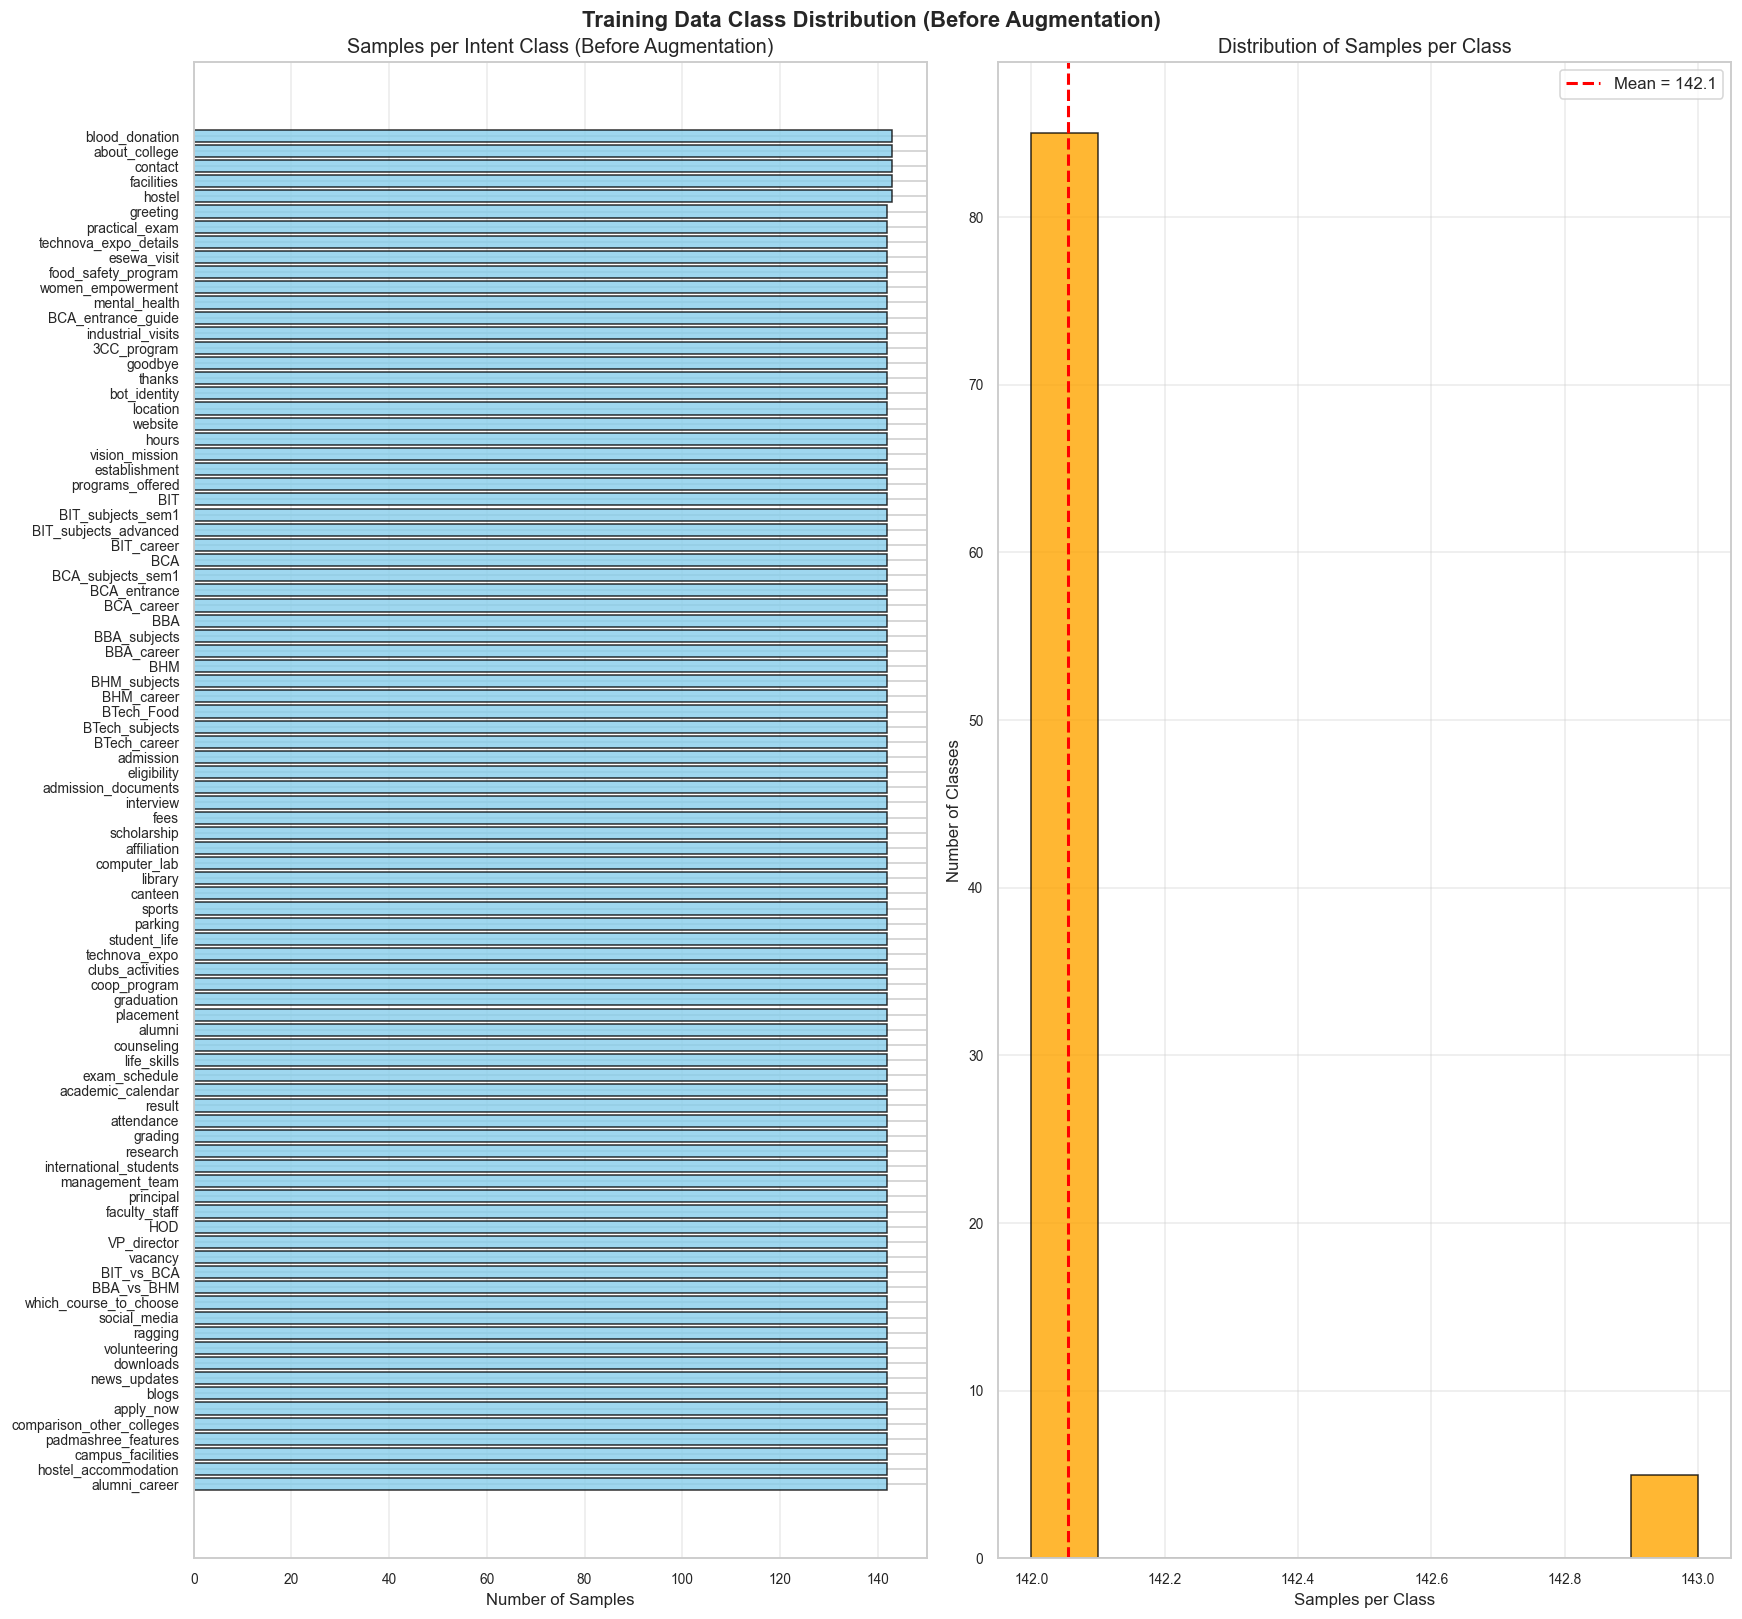

In [7]:
y_all = []
for intent in intents_data["intents"]:
    y_all.extend([intent["tag"]] * len(intent["patterns"]))

class_counts   = Counter(y_all)
classes_sorted = sorted(class_counts, key=class_counts.get, reverse=True)
counts_values  = list(class_counts.values())
mean_val       = np.mean(counts_values)

print(f"Min: {min(counts_values)} | Max: {max(counts_values)} | Mean: {mean_val:.1f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 15))

# Chart 1 - samples per intent
ax1.barh(classes_sorted[::-1], [class_counts[c] for c in classes_sorted[::-1]],
         color="skyblue", edgecolor="black", alpha=0.8)
ax1.set(title="Samples per Intent Class (Before Augmentation)", xlabel="Number of Samples")
ax1.grid(axis="x", alpha=0.4)

# Chart 2 - distribution histogram
ax2.hist(counts_values, bins=10, color="orange", edgecolor="black", alpha=0.8)
ax2.axvline(mean_val, color="red", linestyle="--",
            linewidth=2, label=f"Mean = {mean_val:.1f}")
ax2.set(title="Distribution of Samples per Class",
        xlabel="Samples per Class", ylabel="Number of Classes")
ax2.legend(); ax2.grid(alpha=0.4)

plt.suptitle("Training Data Class Distribution (Before Augmentation)", fontweight="bold")
plt.tight_layout(); plt.show()



In [8]:
import json, difflib, random

# Load dataset
with open("intents_final.json", "r", encoding="utf-8") as f:
    intents_data = json.load(f)

# Synonym dictionary for augmentation
synonyms = {
    "fees": ["tuition", "charges", "cost", "payment"],
    "apply": ["enroll", "register", "admission"],
    "scholarship": ["grant", "financial aid", "funding"],
    "programs": ["courses", "degrees", "subjects"],
    "exam": ["test", "assessment", "evaluation"],
    "vacancy": ["job opening", "position", "opportunity"]
}

def augment_pattern(pattern, synonyms_dict, n=1):
    words = pattern.split()
    new_words = []
    for w in words:
        if w in synonyms_dict and random.random() < 0.5:
            new_words.append(random.choice(synonyms_dict[w]))
        else:
            new_words.append(w)
    return " ".join(new_words)

TARGET_SIZE = 500  # desired number of patterns per intent

for intent in intents_data["intents"]:
    seen = set()
    new_patterns = []
    for p in intent["patterns"]:
        # Deduplicate
        duplicate = False
        for s in seen:
            if difflib.SequenceMatcher(None, p, s).ratio() > 0.85:
                duplicate = True
                break
        if not duplicate:
            seen.add(p)
            new_patterns.append(p)
        else:
            # Replace duplicates with paraphrases
            new_patterns.append(augment_pattern(p, synonyms))

    # Balance: if fewer than TARGET_SIZE, augment until reaching it
    while len(new_patterns) < TARGET_SIZE:
        base = random.choice(new_patterns)
        new_patterns.append(augment_pattern(base, synonyms))

    # Trim if overshoot
    intent["patterns"] = new_patterns[:TARGET_SIZE]

# Save balanced dataset
with open("intents_final_balanced.json", "w", encoding="utf-8") as f:
    json.dump(intents_data, f, indent=2, ensure_ascii=False)

print("Balanced dataset saved as intents_final_balanced.json")


Balanced dataset saved as intents_final_balanced.json


In [9]:
def prepare_training_data(intents_data):
    X, y = [], []
    for intent in intents_data["intents"]:
        tag      = intent["tag"]
        patterns = intent.get("patterns", [])
        if not patterns: continue
        for pattern in patterns:
            processed = preprocess(pattern)
            if processed.strip():
                X.append(processed); y.append(tag)
    print(f"Training samples : {len(X)}")
    print(f"Intent classes   : {len(set(y))}")
    return X, y

X_all, y_all = prepare_training_data(intents_data)

Training samples : 45000
Intent classes   : 90


###  Iteration 2 - Visualization 5: Class Distribution

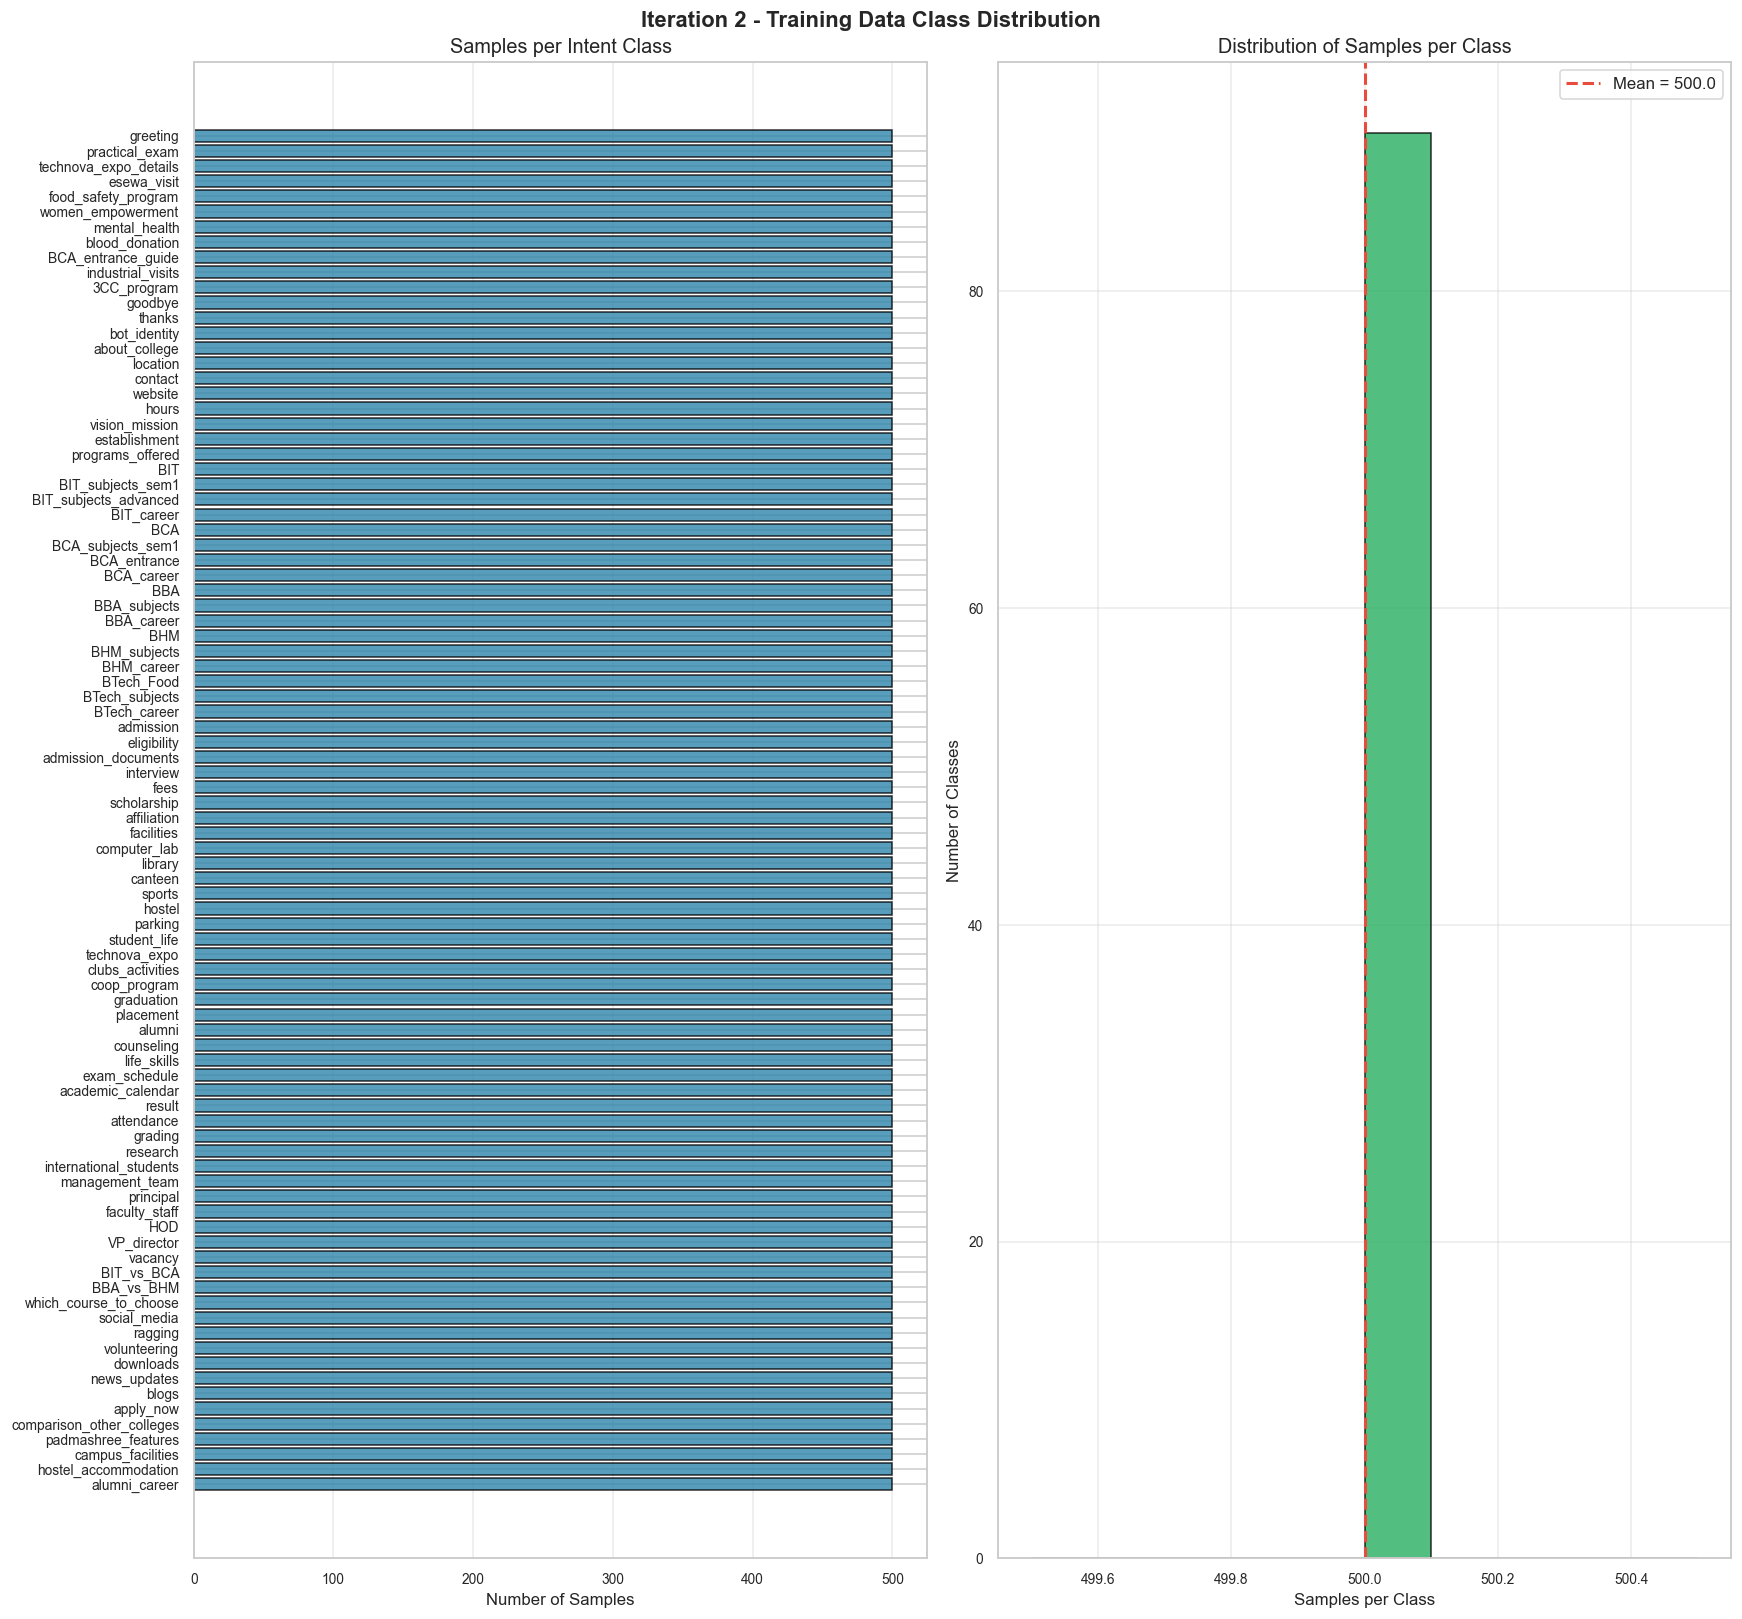

Min: 500 | Max: 500 | Mean: 500.0


In [10]:
class_counts   = Counter(y_all)
classes_sorted = sorted(class_counts, key=class_counts.get, reverse=True)
counts_values  = list(class_counts.values())
mean_val       = np.mean(counts_values)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 15))

# Chart 1 - samples per intent
ax1.barh(classes_sorted[::-1], [class_counts[c] for c in classes_sorted[::-1]],
         color=COLORS["nb"], edgecolor="black", alpha=0.8)
ax1.set(title="Samples per Intent Class", xlabel="Number of Samples")
ax1.grid(axis="x", alpha=0.4)

# Chart 2 - distribution histogram
ax2.hist(counts_values, bins=10, color=COLORS["rule"], edgecolor="black", alpha=0.8)
ax2.axvline(mean_val, color=COLORS["wrong"], linestyle="--",
            linewidth=2, label=f"Mean = {mean_val:.1f}")
ax2.set(title="Distribution of Samples per Class",
        xlabel="Samples per Class", ylabel="Number of Classes")
ax2.legend(); ax2.grid(alpha=0.4)

plt.suptitle("Iteration 2 - Training Data Class Distribution", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Min: {min(counts_values)} | Max: {max(counts_values)} | Mean: {mean_val:.1f}")

## 2.3 Train Naive Bayes Model (Layer 2)

In [46]:
le        = LabelEncoder()
y_encoded = le.fit_transform(y_all)
n_classes = len(le.classes_)

print(f"Dataset: {len(X_all)} patterns, {n_classes} intents")

# Splits data into 4 parts:
# X_train → input patterns for training
# X_test  → input patterns for testing
# y_train → correct labels for training
# y_test  → correct labels for testing

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_encoded,
    test_size=0.20,     # general rule of thumb for dividing datasets 
    random_state=42,    # 42 is just convention (hitchhiker's guide!) 42 is just a pattern for to get consistent result
    stratify=y_encoded  # Ensures EVERY class gets equal 80/20 split
)

# Step 1 of pipeline named "tfidf" (Term Frequency Inverse Document Frequency)
# Converts text into numerical features

# Captures 1, 2, and 3 word combinations:
# "fees kati ho" produces:
# Unigrams:  "fees", "kati", "ho"
# Bigrams:   "fees kati", "kati ho"
# Trigrams:  "fees kati ho"

# Optimized Naive Bayes
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,3),     
        max_features=10000,     #Only keeps top 5000 most important words, gnores rest to reduce noise
        sublinear_tf=True,     #Applies log scaling to word frequency, Without: "fees fees fees fees" = 4, With:"fees fees fees fees" = log(4) = 1.39 Prevents one word dominating everything ✅
        min_df=2,              # (minimum document frequency) Word must appear in at least 2 documents
        max_df=0.95,          #Ignores words appearing in 95%+ documents
        token_pattern=r"[a-zA-Z']+"    #Only keeps letters and apostrophes
    )),
    ("clf", MultinomialNB(
        alpha=0.01,             # Laplace smoothing for unseen words
        fit_prior=True          # Uses class frequency as prior probability
    )),
])

model.fit(X_train, y_train)
y_pred    = model.predict(X_test)
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test  Accuracy : {test_acc*100:.2f}%")
print("\n" + classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    zero_division=0
))

CONFIDENCE_THRESHOLD = 0.30

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('le.pkl', 'wb') as f:
    pickle.dump(le, f)


#     precision = when predicted "fees"
#             how often actually "fees"?
#             18 correct out of 20 predictions = 0.90

# recall    = of all real "fees" questions
#             how many did model find?
#             17 found out of 20 real = 0.85

# f1-score  = balance of precision and recall
#             2 × (precision × recall)
#               ─────────────────────
#               (precision + recall)

# support   = test samples for that class
#             20 = 20% of 100 patterns 

Dataset: 45000 patterns, 90 intents
Train Accuracy : 96.80%
Test  Accuracy : 95.91%

                           precision    recall  f1-score   support

              3CC_program       0.90      1.00      0.95       100
                      BBA       0.99      0.95      0.97       100
               BBA_career       0.99      1.00      1.00       100
             BBA_subjects       0.97      1.00      0.99       100
               BBA_vs_BHM       0.98      1.00      0.99       100
                      BCA       0.92      0.88      0.90       100
               BCA_career       0.96      0.94      0.95       100
             BCA_entrance       0.88      0.93      0.90       100
       BCA_entrance_guide       0.93      0.91      0.92       100
        BCA_subjects_sem1       0.96      1.00      0.98       100
                      BHM       0.92      0.81      0.86       100
               BHM_career       0.88      0.99      0.93       100
             BHM_subjects       0.94      1

## 2.4 Hybrid Prediction Engine

In [12]:
def log_failed_query(user_input, response, confidence, method, 
                     predicted_intent, log_file="fallback_queries.json"):
    try:
        logs = json.load(open(log_file, "r", encoding="utf-8")) if os.path.exists(log_file) else []
        logs.append({
            "timestamp":        datetime.now().isoformat(),
            "user_input":       user_input,
            "predicted_intent": predicted_intent,
            "confidence":       float(confidence),
            "method":           method,
            "bot_response":     response,
        })
        json.dump(logs, open(log_file, "w", encoding="utf-8"), indent=2, ensure_ascii=False)
    except Exception:
        pass

def get_response(user_input, model, le, intents_data, threshold=None):
    if threshold is None:
        threshold = CONFIDENCE_THRESHOLD

    # Layer 1 — Rule Based (instant)
    rule_tag, rule_response = rule_based_match(user_input, intents_data)
    if rule_response:
        return {"response": rule_response, "intent": rule_tag, 
                "confidence": 1.0, "method": "rule-based"}

    # Layer 2 — Naive Bayes
    processed = preprocess(user_input)
    if not processed.strip():
        return {"response": "Could you rephrase that?", 
                "intent": "unknown", "confidence": 0.0, "method": "fallback"}

    proba = model.predict_proba([processed])[0]
    best  = int(np.argmax(proba))
    conf  = float(proba[best])
    tag   = le.inverse_transform([best])[0]

#  predict_proba → gives probability scores for every intent (e.g. [0.02, 0.85, 0.01, ...])
# np.argmax(proba) → finds the index of the highest score
# proba[best] → the actual confidence number (e.g. 0.85)
# le.inverse_transform → converts the index back to the intent name (e.g. "fees")

    # Layer 3 — Confidence Gate
    if conf < threshold:
        return {"response": "I'm not sure. Could you rephrase or call +977-1-4112252.",
                "intent": tag, "confidence": conf, "method": "fallback"}

    # Fetch response from intents.json
    for intent in intents_data["intents"]:
        if intent["tag"] == tag and intent.get("responses"):
            return {"response": random.choice(intent["responses"]),
                    "intent": tag, "confidence": conf, "method": "naive-bayes"}

    return {"response": "Intent found but no response configured.",
            "intent": tag, "confidence": conf, "method": "naive-bayes"}

print("Iteration 2 — 3-Layer Hybrid engine ready (Rule → NB → Confidence Gate)")

Iteration 2 — 3-Layer Hybrid engine ready (Rule → NB → Confidence Gate)


---
# Iteration 3 - Evaluation & Analysis


### Iteration 3 - Visualization 6: Learning Curve (Train vs Validation)

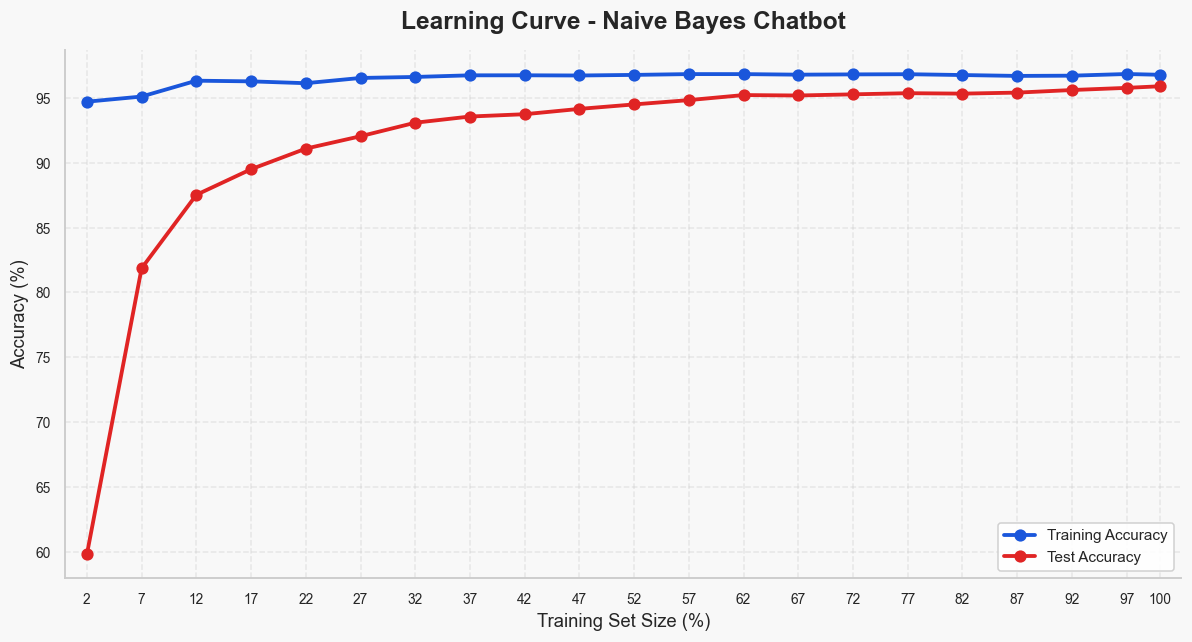

Final Train Accuracy : 96.80%
Final Test  Accuracy : 95.91%
Overfit Gap          : 0.89%


In [47]:
from sklearn.metrics import accuracy_score

train_sizes_pct = list(range(2, 101, 5)) + [100]
train_acc_list  = []
test_acc_list   = []

for pct in train_sizes_pct:
    n_samples = int(len(X_train) * pct / 100)
    if n_samples < 10:
        train_acc_list.append(np.nan)
        test_acc_list.append(np.nan)
        continue

    X_sub = X_train[:n_samples]
    y_sub = y_train[:n_samples]

    fold_model = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 3),
            max_features=10000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            token_pattern=r"[a-zA-Z']+"
        )),
        ("clf", MultinomialNB(alpha=0.01, fit_prior=True)),
    ])

    fold_model.fit(X_sub, y_sub)
    train_acc_list.append(accuracy_score(y_sub,   fold_model.predict(X_sub)))
    test_acc_list.append( accuracy_score(y_test,  fold_model.predict(X_test)))

# ── Plot ───────────────────────────────────────────────────────────────────
t_arr = np.array(train_acc_list, dtype=float)
v_arr = np.array(test_acc_list,  dtype=float)
mask  = ~np.isnan(t_arr)
x_pct = np.array(train_sizes_pct)[mask]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#F8F8F8")
ax.set_facecolor("#F8F8F8")
ax.plot(x_pct, t_arr[mask]*100, "o-", color="#1A56DB",
        lw=2.5, ms=7, label="Training Accuracy", zorder=3)
ax.plot(x_pct, v_arr[mask]*100, "o-", color="#E02424",
        lw=2.5, ms=7, label="Test Accuracy",     zorder=3)
ax.set_title("Learning Curve - Naive Bayes Chatbot",
             fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Training Set Size (%)", fontsize=12)
ax.set_ylabel("Accuracy (%)",          fontsize=12)
ax.set_xticks(x_pct)
ax.set_xlim(x_pct[0] - 2, 102)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.4, linestyle="--", color="#CCCCCC")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f"Final Train Accuracy : {t_arr[mask][-1]*100:.2f}%")
print(f"Final Test  Accuracy : {v_arr[mask][-1]*100:.2f}%")
print(f"Overfit Gap          : {(t_arr[mask][-1]-v_arr[mask][-1])*100:.2f}%")

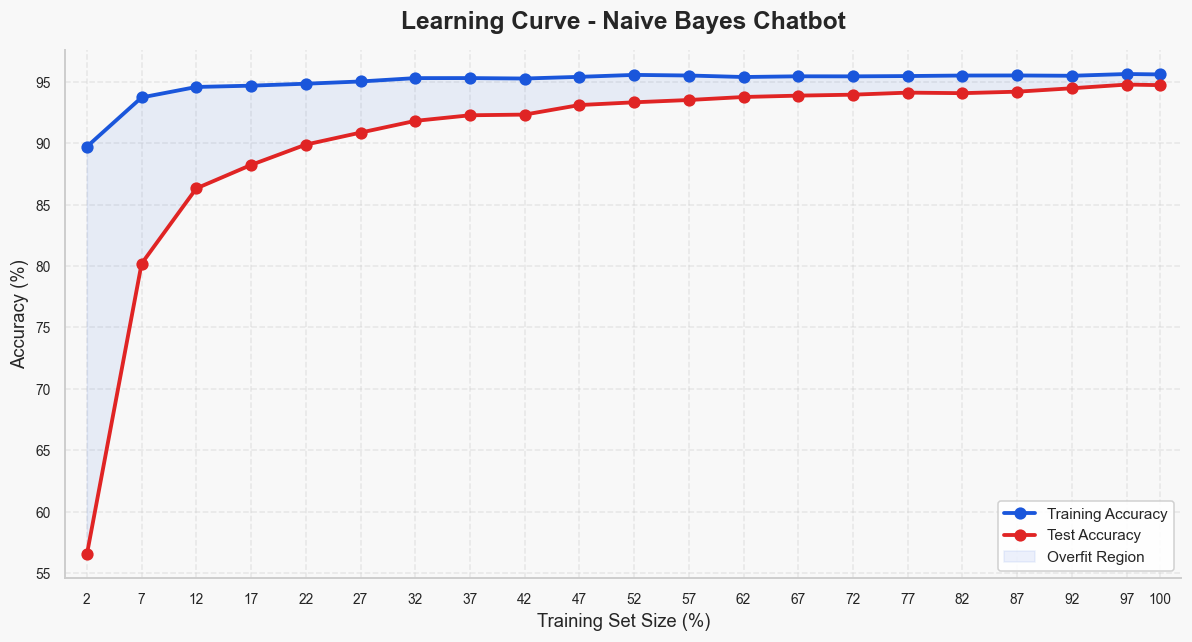

Final Train Accuracy : 95.61%
Final Test  Accuracy : 94.73%
Overfit Gap          : 0.87%


In [31]:
from sklearn.metrics import accuracy_score

train_sizes_pct = list(range(2, 101, 5)) + [100]
train_acc_list  = []
test_acc_list   = []

for pct in train_sizes_pct:
    n_samples = len(X_train) if pct == 100 else int(len(X_train) * pct / 100)
    if n_samples < 10:
        train_acc_list.append(np.nan)
        test_acc_list.append(np.nan)
        continue

    X_sub = X_train[:n_samples]
    y_sub = y_train[:n_samples]

    fold_model = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),        # ✅ matches main model
            max_features=5000,
            sublinear_tf=True,
            min_df=2,
            max_df=0.95,
            token_pattern=r"[a-zA-Z']+"
        )),
        ("clf", MultinomialNB(alpha=0.1, fit_prior=True)),   # ✅ matches main model
    ])

    fold_model.fit(X_sub, y_sub)
    train_acc_list.append(accuracy_score(y_sub,  fold_model.predict(X_sub)))
    test_acc_list.append( accuracy_score(y_test, fold_model.predict(X_test)))

# ── Plot ───────────────────────────────────────────────────────────────────
t_arr = np.array(train_acc_list, dtype=float)
v_arr = np.array(test_acc_list,  dtype=float)
mask  = ~np.isnan(t_arr)
x_pct = np.array(train_sizes_pct)[mask]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#F8F8F8")
ax.set_facecolor("#F8F8F8")
ax.plot(x_pct, t_arr[mask]*100, "o-", color="#1A56DB",
        lw=2.5, ms=7, label="Training Accuracy", zorder=3)
ax.plot(x_pct, v_arr[mask]*100, "o-", color="#E02424",
        lw=2.5, ms=7, label="Test Accuracy",     zorder=3)
ax.fill_between(x_pct, t_arr[mask]*100, v_arr[mask]*100,
                alpha=0.08, color="#1A56DB", label="Overfit Region")
ax.set_title("Learning Curve - Naive Bayes Chatbot",
             fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Training Set Size (%)", fontsize=12)
ax.set_ylabel("Accuracy (%)",          fontsize=12)
ax.set_xticks(x_pct)
ax.set_xlim(x_pct[0] - 2, 102)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.4, linestyle="--", color="#CCCCCC")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f"Final Train Accuracy : {t_arr[mask][-1]*100:.2f}%")
print(f"Final Test  Accuracy : {v_arr[mask][-1]*100:.2f}%")
print(f"Overfit Gap          : {(t_arr[mask][-1]-v_arr[mask][-1])*100:.2f}%")

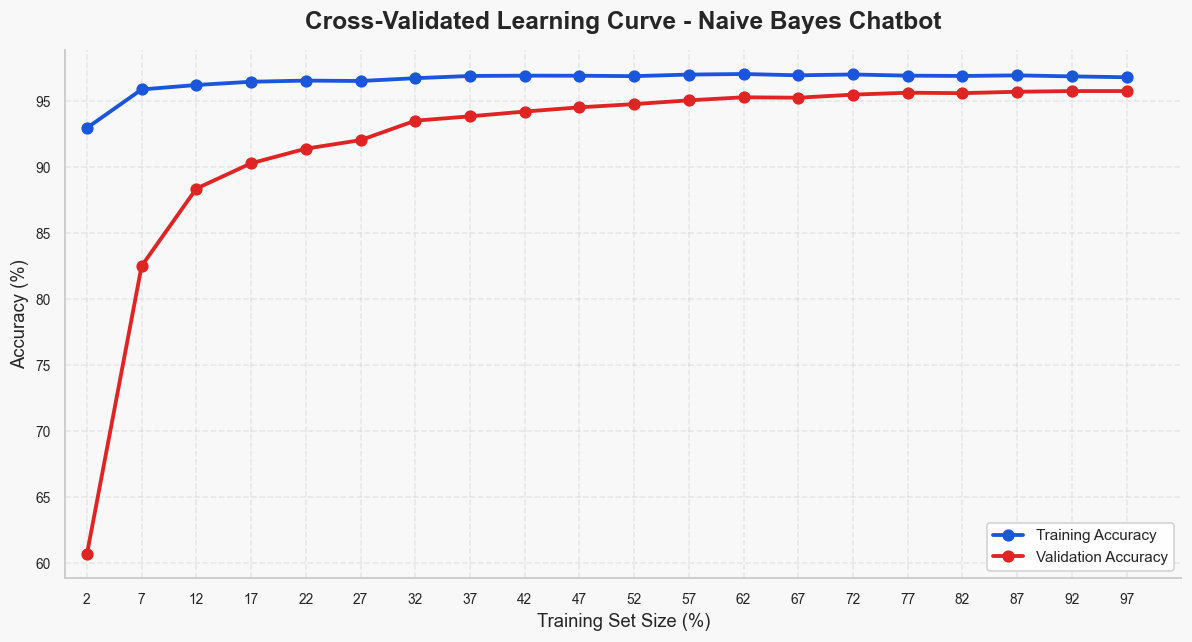

Final Train Accuracy (mean): 96.80%
Final Val   Accuracy (mean): 95.76%
Overfit Gap (mean): 1.04%


In [48]:
from sklearn.utils import shuffle as sk_shuffle  #for keras model only
from sklearn.metrics import accuracy_score

# shuffle full dataset
X_all_arr      = np.array(X_all)
X_shuf, y_shuf = sk_shuffle(X_all_arr, y_encoded, random_state=42)

train_sizes_pct = list(range(2, 101, 5))
train_acc_list  = []
val_acc_list    = []

for pct in train_sizes_pct:
    n_samples = int(len(X_shuf) * pct / 100)
    X_sub     = list(X_shuf[:n_samples])
    y_sub     = y_shuf[:n_samples]

    min_class = int(np.bincount(y_sub).min())
    if min_class < 2:
        train_acc_list.append(np.nan)
        val_acc_list.append(np.nan)
        continue

    n_splits = max(3, min(5, min_class))
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_train_acc, fold_val_acc = [], []

    for tr_idx, val_idx in skf.split(X_sub, y_sub):
        X_tr  = [X_sub[i] for i in tr_idx];  y_tr  = y_sub[tr_idx]
        X_val = [X_sub[i] for i in val_idx]; y_val = y_sub[val_idx]

        fold_model = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=(1, 3),
                max_features=10000,
                sublinear_tf=True,
                min_df=2,
                max_df=0.95,
                token_pattern=r"[a-zA-Z']+"
            )),
            ("clf", MultinomialNB(alpha=0.01, fit_prior=True)),
        ])
        fold_model.fit(X_tr, y_tr)

        fold_train_acc.append(accuracy_score(y_tr,  fold_model.predict(X_tr)))
        fold_val_acc.append(  accuracy_score(y_val, fold_model.predict(X_val)))

    train_acc_list.append(np.mean(fold_train_acc))
    val_acc_list.append(  np.mean(fold_val_acc))

# Plot accuracy curve
t_arr = np.array(train_acc_list, dtype=float)
v_arr = np.array(val_acc_list,   dtype=float)
mask  = ~np.isnan(t_arr)
x_pct = np.array(train_sizes_pct)[mask]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#F8F8F8")
ax.set_facecolor("#F8F8F8")

ax.plot(x_pct, t_arr[mask]*100, "o-", color="#1A56DB",
        lw=2.5, ms=7, label="Training Accuracy",   zorder=3)
ax.plot(x_pct, v_arr[mask]*100, "o-", color="#E02424",
        lw=2.5, ms=7, label="Validation Accuracy", zorder=3)

ax.set_title("Cross-Validated Learning Curve - Naive Bayes Chatbot",
             fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Training Set Size (%)", fontsize=12)
ax.set_ylabel("Accuracy (%)",          fontsize=12)
ax.set_xticks(x_pct)
ax.set_xlim(x_pct[0] - 2, 102)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.4, linestyle="--", color="#CCCCCC")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("cv_learning_curve.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f"Final Train Accuracy (mean): {t_arr[mask][-1]*100:.2f}%")
print(f"Final Val   Accuracy (mean): {v_arr[mask][-1]*100:.2f}%")
print(f"Overfit Gap (mean): {(t_arr[mask][-1]-v_arr[mask][-1])*100:.2f}%")


### Iteration 3 - Visualization 8: Log Loss Curve

In [ ]:
def safe_log_loss(y_true, fold_model, X, n_classes):
    proba         = fold_model.predict_proba(X)
    seen          = fold_model.named_steps["clf"].classes_
    full          = np.zeros((len(X), n_classes))
    full[:, seen] = proba
    full          = np.clip(full, 1e-10, 1)
    return log_loss(y_true, full, labels=np.arange(n_classes))

# shuffle full dataset
X_all_arr      = np.array(X_all)
X_shuf, y_shuf = sk_shuffle(X_all_arr, y_encoded, random_state=42)

train_sizes_pct = list(range(2, 101, 5)) + [100]
train_loss_list = []
val_loss_list   = []

for pct in train_sizes_pct:
    n_samples = int(len(X_shuf) * pct / 100)
    X_sub     = list(X_shuf[:n_samples])
    y_sub     = y_shuf[:n_samples]

    min_class = int(np.bincount(y_sub).min())

    if min_class < 2:
        train_loss_list.append(np.nan)
        val_loss_list.append(np.nan)
        continue

    
    n_splits = max(3, min(5, min_class))
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_train_loss, fold_val_loss = [], []

    for tr_idx, val_idx in skf.split(X_sub, y_sub):
        X_tr  = [X_sub[i] for i in tr_idx];  y_tr  = y_sub[tr_idx]
        X_val = [X_sub[i] for i in val_idx]; y_val = y_sub[val_idx]

        # alpha=1.0 stops memorisation
        fold_model = Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=(1, 2),    
                max_features=5000,      
                sublinear_tf=True,
                min_df=2,               
                max_df=0.95,
                token_pattern=r"[a-zA-Z']+"
            )),
            ("clf", MultinomialNB(alpha=1.0, fit_prior=True)),  
        ])
        fold_model.fit(X_tr, y_tr)

        fold_train_loss.append(safe_log_loss(y_tr,  fold_model, X_tr,  n_classes))
        fold_val_loss.append(  safe_log_loss(y_val, fold_model, X_val, n_classes))

    train_loss_list.append(np.mean(fold_train_loss))
    val_loss_list.append(  np.mean(fold_val_loss))

# Restore full model
model.fit(X_train, y_train)

#  plot 
t_arr = np.array(train_loss_list, dtype=float)
v_arr = np.array(val_loss_list,   dtype=float)
mask  = ~np.isnan(t_arr)
x_pct = np.array(train_sizes_pct)[mask]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#F8F8F8")
ax.set_facecolor("#F8F8F8")

ax.plot(x_pct, t_arr[mask], "o-", color="#1A56DB",
        lw=2.5, ms=7, label="Training Loss (Log Loss)",   zorder=3)
ax.plot(x_pct, v_arr[mask], "o-", color="#E02424",
        lw=2.5, ms=7, label="Validation Loss (Log Loss)", zorder=3)

ax.set_title("Loss Curve of Naive Bayes Chatbot",
             fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Training Set Size (%)", fontsize=12)
ax.set_ylabel("Log Loss",              fontsize=12)
ax.set_xticks(x_pct)
ax.set_xlim(x_pct[0] - 2, 102)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.4, linestyle="--", color="#CCCCCC")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("loss_curve_final.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f"Final Train Loss      : {t_arr[mask][-1]:.4f}")
print(f"Final Validation Loss : {v_arr[mask][-1]:.4f}")
print(f"Final Gap             : {abs(v_arr[mask][-1] - t_arr[mask][-1]):.4f}")

### Iteration 3 — Visualization 9: Confusion Matrix

In [17]:
# cm = confusion_matrix(y_test, y_pred)
# fig, ax = plt.subplots(figsize=(max(10, n_classes*0.55), max(8, n_classes*0.5)))
# sns.heatmap(cm, annot=(n_classes<=20), fmt="d", cmap="Blues",
#             xticklabels=le.classes_, yticklabels=le.classes_,
#             ax=ax, linewidths=0.3)
# ax.set_title("Iteration 3 — Confusion Matrix: Naive Bayes on Test Set")
# ax.set_xlabel("Predicted Intent"); ax.set_ylabel("True Intent")
# ax.tick_params(axis="x", rotation=90); ax.tick_params(axis="y", rotation=0)
# plt.tight_layout(); plt.show()
# print(f"Test samples: {len(y_test)} | Classes: {n_classes}")

### Iteration 3 — Visualization 10: ROC Curve (Micro-Average) Receiver Operating Characteristic.

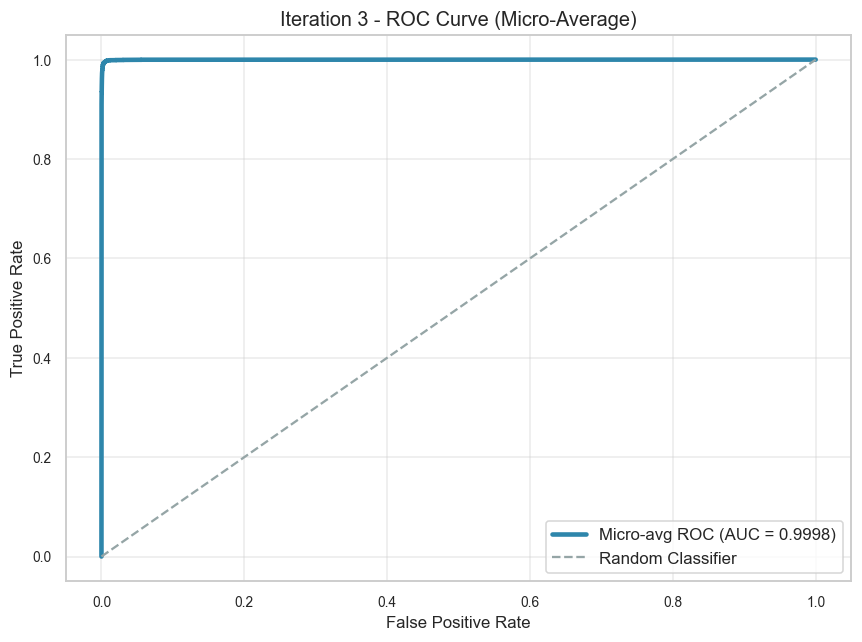

ROC AUC (micro): 0.9998


In [18]:
y_score    = model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_micro, tpr_micro, color=COLORS["nb"], lw=3,
        label=f"Micro-avg ROC (AUC = {roc_auc_micro:.4f})")
ax.plot([0,1],[0,1], "--", color=COLORS["neutral"], lw=1.5, label="Random Classifier")
ax.set_title("Iteration 3 - ROC Curve (Micro-Average)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right"); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()
print(f"ROC AUC (micro): {roc_auc_micro:.4f}")

###  Iteration 3 — Visualization 11: Per-Intent F1 Heatmap

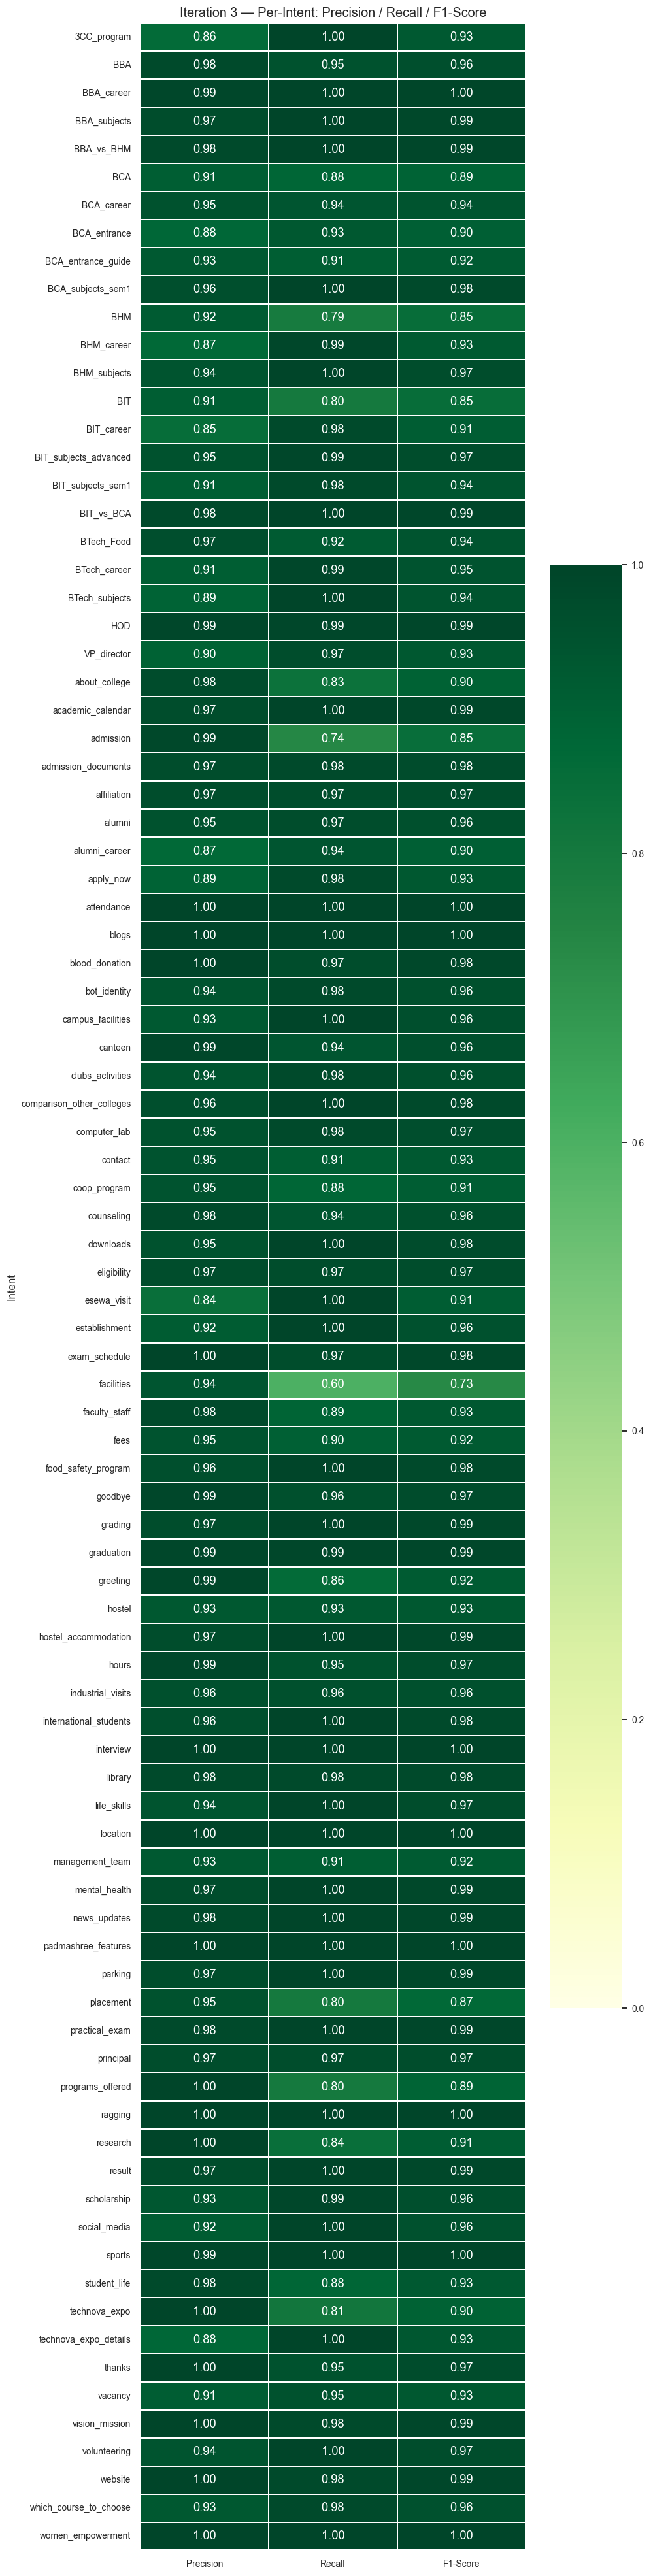

Macro F1: 0.952 | Weighted F1: 0.952


In [19]:
report_dict = classification_report(y_test, y_pred,
              target_names=le.classes_, zero_division=0, output_dict=True)
metrics_df = pd.DataFrame({
    "Precision": [report_dict[c]["precision"] for c in le.classes_],
    "Recall":    [report_dict[c]["recall"]    for c in le.classes_],
    "F1-Score":  [report_dict[c]["f1-score"]  for c in le.classes_],
}, index=le.classes_)

fig, ax = plt.subplots(figsize=(9, max(6, len(le.classes_)*0.4)))
sns.heatmap(metrics_df, annot=True, fmt=".2f", cmap="YlGn",
            vmin=0, vmax=1, ax=ax, linewidths=0.3, cbar_kws={"shrink":0.6})
ax.set_title("Iteration 3 — Per-Intent: Precision / Recall / F1-Score")
ax.set_ylabel("Intent"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
print(f"Macro F1: {report_dict['macro avg']['f1-score']:.3f} | Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")

## 3.1 Test Cases (14 Scenarios)

In [20]:
TEST_CASES = [
    {"query":"What courses do you offer?",        "expected":"programs_offered","category":"General"},
    {"query":"How can I apply to Padmashree?",    "expected":"admission",       "category":"Admission"},
    {"query":"Tell me about the college",         "expected":"about_college",   "category":"General"},
    {"query":"What is your contact number?",      "expected":"contact",         "category":"Contact"},
    {"query":"Hello! How are you?",               "expected":"greeting",        "category":"Greeting"},
    {"query":"How much is the BCA fee?",          "expected":"fees",            "category":"Fees"},
    {"query":"Kaha xa padmashree college dai?",   "expected":"location",        "category":"Nepali"},
    {"query":"BCA padhna xa bro",                 "expected":"BCA",             "category":"Nepali"},
    {"query":"Do you have scholarships?",         "expected":"scholarship",     "category":"Fees"},
    {"query":"What are the office timings?",      "expected":"hours",           "category":"General"},
    {"query":"Is there hostel facility?",         "expected":"hostel",          "category":"Facility"},
    {"query":"kasari linu admission form bro",    "expected":"admission",       "category":"Nepali"},
    {"query":"bit course scope k xa?",            "expected":"BIT",             "category":"Course"},
    {"query":"Goodbye, thanks for help!",         "expected":"goodbye",         "category":"Greeting"},
]

results = []
print(f"{'#':<4} {'Query':<42} {'Expected':<22} {'Predicted':<22} {'Match':<6} {'Conf':>6} {'Method'}")
print("-"*120)
for idx, tc in enumerate(TEST_CASES, 1):
    res   = get_response(tc["query"], model, le, intents_data)
    match = res["intent"] == tc["expected"]
    results.append({
        "Query":       tc["query"], "Category":   tc["category"],
        "Expected":    tc["expected"],"Predicted": res["intent"],
        "Match":       "Yes" if match else "No",
        "Confidence":  res["confidence"],
        "Method":      res["method"],
        "Conf Status": "HIGH" if res["confidence"]>=CONFIDENCE_THRESHOLD else "LOW",
    })
    print(f"{idx:<4} {tc['query'][:40]:<42} {tc['expected']:<22} {res['intent']:<22} "
          f"{'Yes' if match else 'No':<6} {res['confidence']:>6.3f} {res['method']}")

results_df = pd.DataFrame(results)
correct = results_df["Match"].eq("Yes").sum()
print(f"\nTest Accuracy: {correct}/{len(results)} = {correct/len(results)*100:.1f}%")

#    Query                                      Expected               Predicted              Match    Conf Method
------------------------------------------------------------------------------------------------------------------------
1    What courses do you offer?                 programs_offered       programs_offered       Yes     1.000 rule-based
2    How can I apply to Padmashree?             admission              admission              Yes     1.000 rule-based
3    Tell me about the college                  about_college          about_college          Yes     0.473 naive-bayes
4    What is your contact number?               contact                contact                Yes     1.000 rule-based
5    Hello! How are you?                        greeting               greeting               Yes     0.989 naive-bayes
6    How much is the BCA fee?                   fees                   fees                   Yes     0.965 naive-bayes
7    Kaha xa padmashree college dai?           

### Iteration 3 — Visualization 12: Test Case Analysis

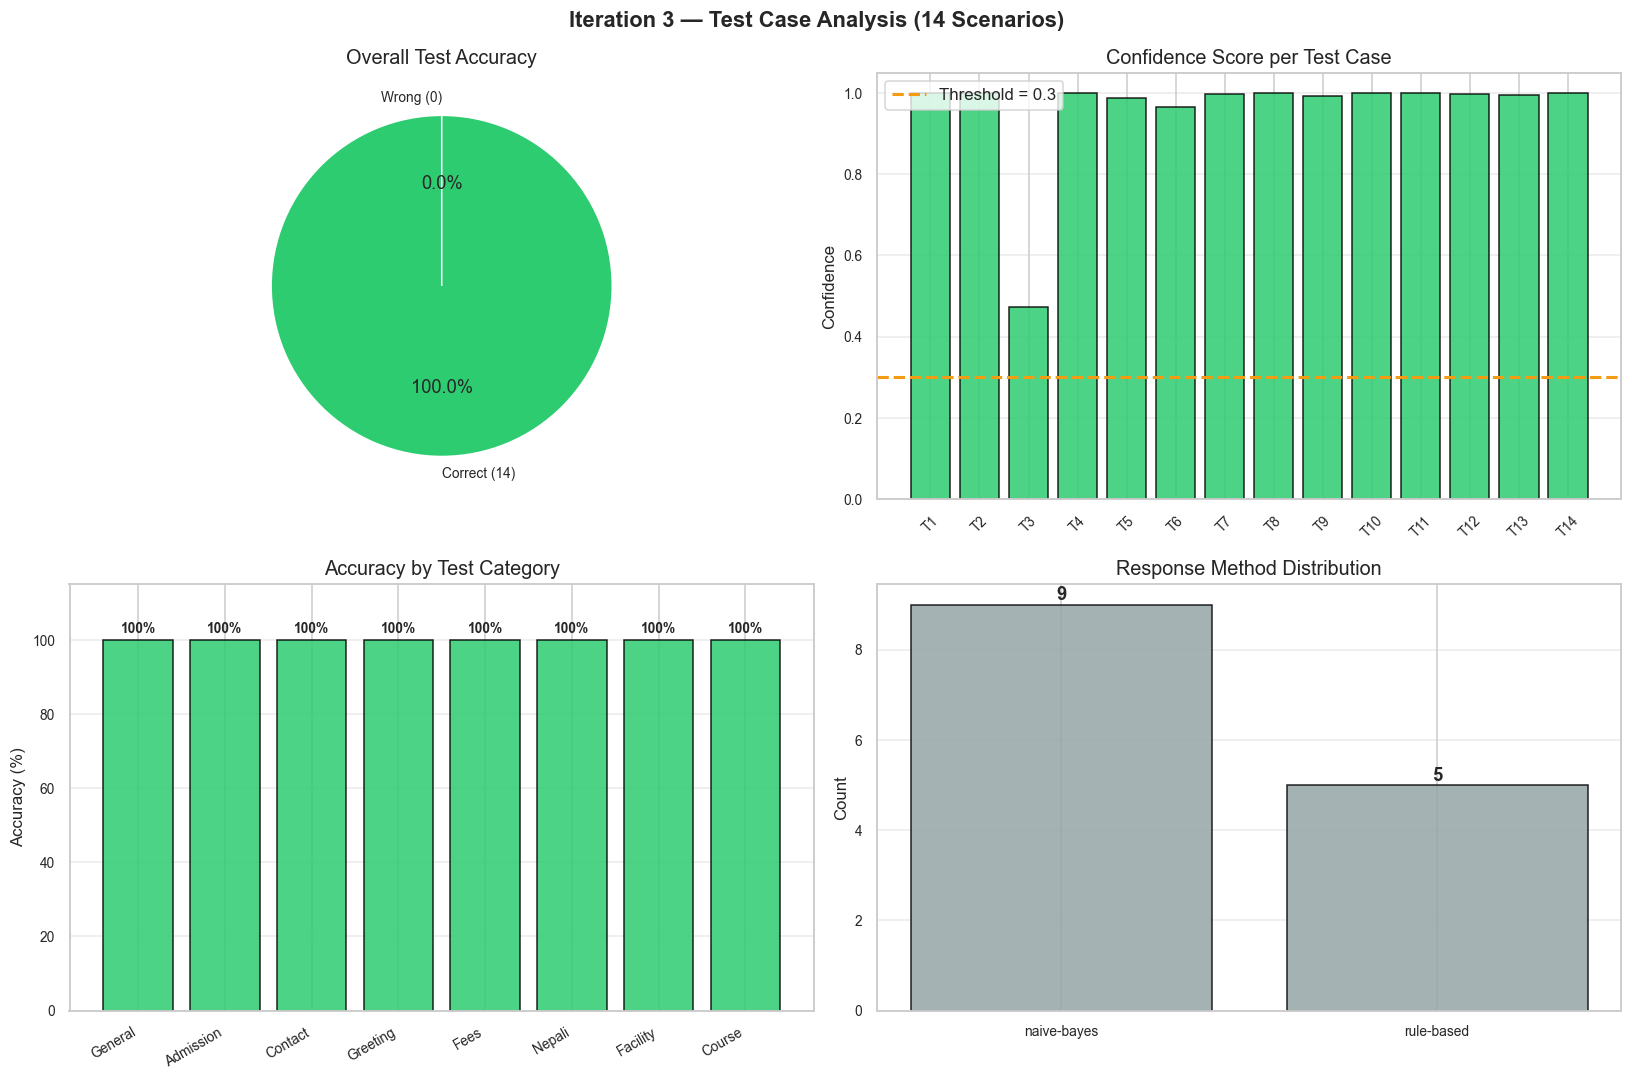

In [21]:
confs  = results_df["Confidence"].tolist()
conf_colors = [COLORS["correct"] if c >= CONFIDENCE_THRESHOLD 
               else COLORS["wrong"] for c in confs]

cat_stats = defaultdict(lambda: {"correct": 0, "total": 0})
for r in results:
    cat_stats[r["Category"]]["total"] += 1
    if r["Match"] == "Yes":
        cat_stats[r["Category"]]["correct"] += 1

cat_names = list(cat_stats.keys())
cat_accs  = [cat_stats[c]["correct"] / cat_stats[c]["total"] * 100 for c in cat_names]
cat_colors = [COLORS["correct"] if a == 100 else 
              COLORS["fallback"] if a >= 50 else 
              COLORS["wrong"] for a in cat_accs]

method_counts = results_df["Method"].value_counts()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Chart 1 — Pie: overall accuracy
ax1.pie([correct, len(results) - correct],
        labels=[f"Correct ({correct})", f"Wrong ({len(results)-correct})"],
        autopct="%1.1f%%",
        colors=[COLORS["correct"], COLORS["wrong"]],
        startangle=90)
ax1.set_title("Overall Test Accuracy")

# Chart 2 — Bar: confidence per test case
ax2.bar(range(len(confs)), confs, color=conf_colors, edgecolor="black", alpha=0.85)
ax2.axhline(CONFIDENCE_THRESHOLD, color=COLORS["fallback"],
            linestyle="--", lw=2, label=f"Threshold = {CONFIDENCE_THRESHOLD}")
ax2.set_xticks(range(len(confs)))
ax2.set_xticklabels([f"T{i+1}" for i in range(len(confs))], rotation=45)
ax2.set(title="Confidence Score per Test Case", ylabel="Confidence")
ax2.legend(); ax2.grid(axis="y", alpha=0.4)

# Chart 3 — Bar: accuracy by category
ax3.bar(range(len(cat_names)), cat_accs, color=cat_colors, edgecolor="black", alpha=0.85)
ax3.set_xticks(range(len(cat_names)))                        
ax3.set_xticklabels(cat_names, rotation=30, ha="right")
ax3.set(title="Accuracy by Test Category", ylabel="Accuracy (%)")
ax3.set_ylim(0, 115)
ax3.grid(axis="y", alpha=0.4)
for i, a in enumerate(cat_accs):
    ax3.text(i, a + 2, f"{a:.0f}%", ha="center", fontsize=9, fontweight="bold")

# Chart 4 — Bar: method distribution
ax4.bar(range(len(method_counts)),
        method_counts.values,
        color=[COLORS.get(m.replace("-", "_"), COLORS["neutral"]) 
               for m in method_counts.index],
        edgecolor="black", alpha=0.85)
ax4.set_xticks(range(len(method_counts)))                    
ax4.set_xticklabels(method_counts.index)
ax4.set(title="Response Method Distribution", ylabel="Count")
ax4.grid(axis="y", alpha=0.4)
for i, (m, v) in enumerate(zip(method_counts.index, method_counts.values)):
    ax4.text(i, v + 0.1, str(v), ha="center", fontweight="bold")

plt.suptitle("Iteration 3 — Test Case Analysis (14 Scenarios)", fontweight="bold")
plt.tight_layout(); plt.show()

### Iteration 3 — Visualization 13: Layer-wise Performance

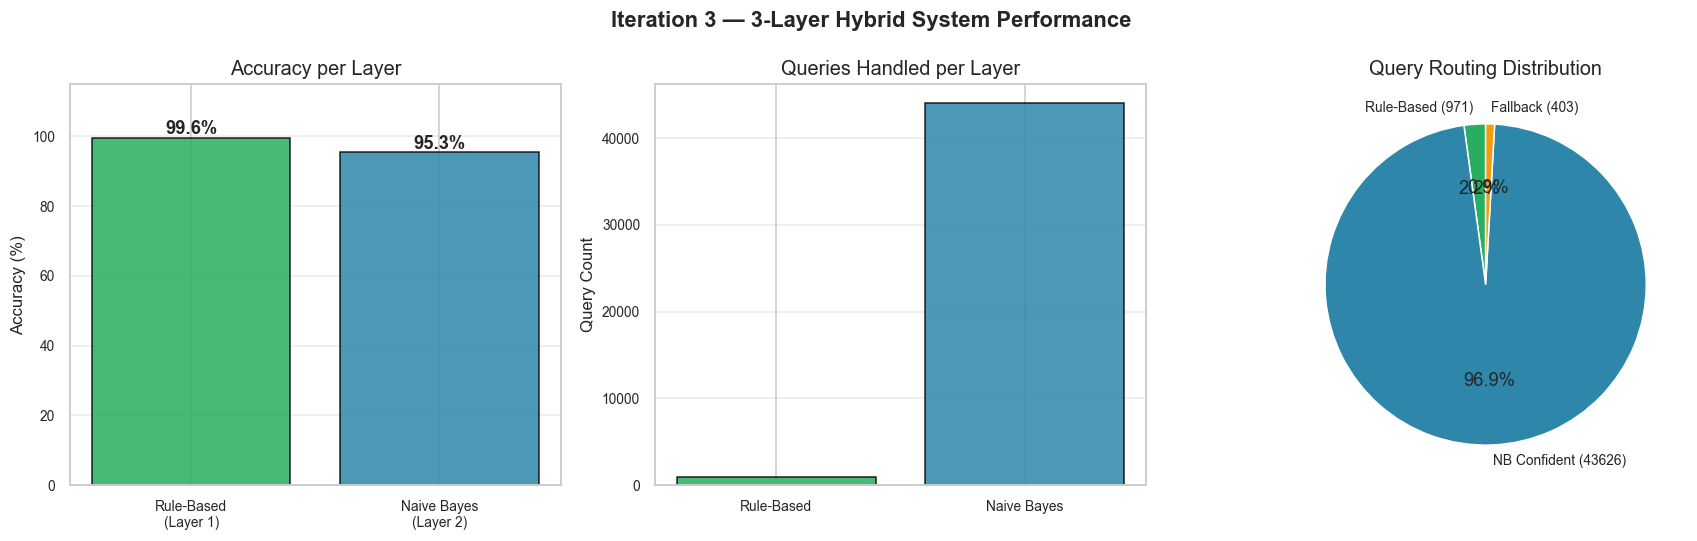

Rule: 971 → 967 correct (99.6%)
NB  : 44029 → 41976 correct (95.3%)
Fallback: 403

Iteration 3 Complete — Evaluation done, weaknesses identified for Iteration 4


In [22]:
rule_matched = rule_correct = nb_matched = nb_correct = conf_filtered = 0

for pattern, true_intent in zip(X_all, y_all):
    r_tag, r_resp = rule_based_match(pattern, intents_data)
    if r_resp:
        rule_matched += 1
        if r_tag == true_intent: rule_correct += 1
    else:
        proc = preprocess(pattern)
        if proc.strip():
            proba = model.predict_proba([proc])[0]
            best  = int(np.argmax(proba)); conf = float(proba[best])
            pred  = le.inverse_transform([best])[0]
            nb_matched += 1
            if pred == true_intent: nb_correct += 1
            if conf < CONFIDENCE_THRESHOLD: conf_filtered += 1

rule_acc = rule_correct/rule_matched if rule_matched else 0
nb_acc   = nb_correct/nb_matched     if nb_matched   else 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

layers = ["Rule-Based\n(Layer 1)","Naive Bayes\n(Layer 2)"]
accs   = [rule_acc*100, nb_acc*100]
bars = axes[0].bar(layers, accs, color=[COLORS["rule"],COLORS["nb"]],
                    edgecolor="black", alpha=0.85)
for b,a in zip(bars,accs):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 f"{a:.1f}%", ha="center", fontweight="bold")
axes[0].set_ylim(0,115); axes[0].set_title("Accuracy per Layer")
axes[0].set_ylabel("Accuracy (%)"); axes[0].grid(axis="y", alpha=0.4)

axes[1].bar(["Rule-Based","Naive Bayes"], [rule_matched, nb_matched],
            color=[COLORS["rule"],COLORS["nb"]], edgecolor="black", alpha=0.85)
axes[1].set_title("Queries Handled per Layer")
axes[1].set_ylabel("Query Count"); axes[1].grid(axis="y", alpha=0.4)

axes[2].pie([rule_matched, nb_matched-conf_filtered, conf_filtered],
            labels=[f"Rule-Based ({rule_matched})",
                    f"NB Confident ({nb_matched-conf_filtered})",
                    f"Fallback ({conf_filtered})"],
            autopct="%1.1f%%",
            colors=[COLORS["rule"],COLORS["nb"],COLORS["fallback"]], startangle=90)
axes[2].set_title("Query Routing Distribution")

plt.suptitle("Iteration 3 — 3-Layer Hybrid System Performance", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Rule: {rule_matched} → {rule_correct} correct ({rule_acc*100:.1f}%)")
print(f"NB  : {nb_matched} → {nb_correct} correct ({nb_acc*100:.1f}%)")
print(f"Fallback: {conf_filtered}")
print("\nIteration 3 Complete — Evaluation done, weaknesses identified for Iteration 4")

In [23]:
# print("\nTop Fallback Intents:")
# fallback_intents = []
# for pattern, true_intent in zip(X_all, y_all):
#     r_tag, r_resp = rule_based_match(pattern, intents_data)
#     if not r_resp:
#         proc = preprocess(pattern)
#         if proc.strip():
#             proba = model.predict_proba([proc])[0]
#             conf  = float(proba[np.argmax(proba)])
#             if conf < CONFIDENCE_THRESHOLD:
#                 fallback_intents.append(true_intent)

# # Show which intents fall back most
# from collections import Counter
# for intent, count in Counter(fallback_intents).most_common(10):
#     print(f"{intent:30s} → {count} fallbacks")

---
# Iteration 4 - Refinement & Final Report Dashboard


### Iteration 3 - Visualization 7: Learning Curve (Train vs Validation)

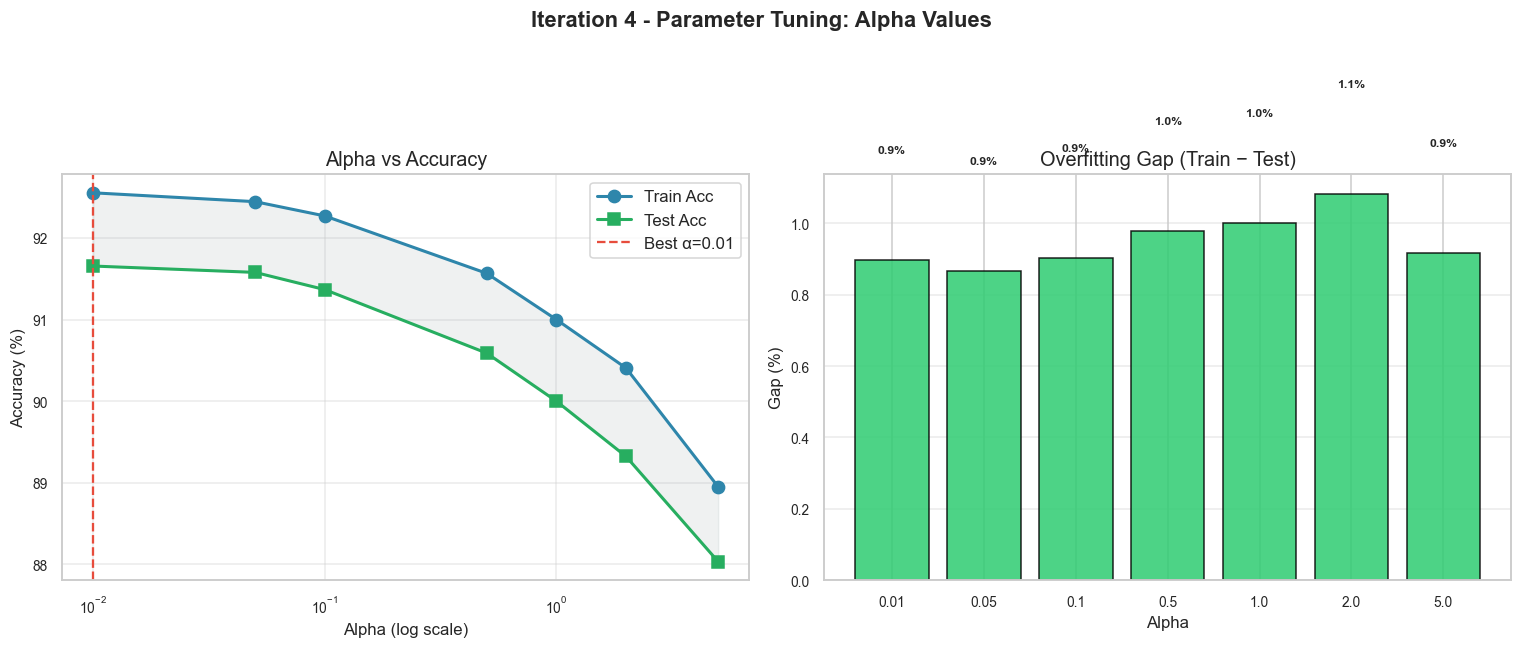

 Alpha Train Acc (%) Test  Acc (%) Gap (%)
  0.01         92.55         91.66    0.90
  0.05         92.44         91.58    0.87
  0.10         92.27         91.37    0.90
  0.50         91.57         90.59    0.98
  1.00         91.00         90.00    1.00
  2.00         90.41         89.32    1.08
  5.00         88.95         88.03    0.92

Best alpha: 0.01 | Model uses alpha=0.01


In [33]:
alpha_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
train_accs_alpha, test_accs_alpha = [], []

for alpha in alpha_values:
    m = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,1), max_features=6000,
                                   sublinear_tf=True, min_df=1, max_df=0.95,
                                   token_pattern=r"[a-zA-Z']+")),
        ("clf",  MultinomialNB(alpha=alpha, fit_prior=True)),
    ])
    m.fit(X_train, y_train)
    train_accs_alpha.append(accuracy_score(y_train, m.predict(X_train))*100)
    test_accs_alpha.append( accuracy_score(y_test,  m.predict(X_test))*100)

gaps = [t-te for t,te in zip(train_accs_alpha, test_accs_alpha)]
best_alpha = alpha_values[np.argmax(test_accs_alpha)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(alpha_values, train_accs_alpha, "o-", color=COLORS["nb"],   lw=2, ms=8, label="Train Acc")
axes[0].plot(alpha_values, test_accs_alpha,  "s-", color=COLORS["rule"], lw=2, ms=8, label="Test Acc")
axes[0].fill_between(alpha_values, train_accs_alpha, test_accs_alpha, alpha=0.15, color=COLORS["neutral"])
axes[0].axvline(best_alpha, color=COLORS["wrong"], linestyle="--", lw=1.5, label=f"Best α={best_alpha}")
axes[0].set_xscale("log"); axes[0].set_title("Alpha vs Accuracy")
axes[0].set_xlabel("Alpha (log scale)"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(alpha=0.4)

gap_colors = [COLORS["correct"] if g<5 else COLORS["fallback"] if g<15 else COLORS["wrong"]
              for g in gaps]
axes[1].bar(range(len(alpha_values)), gaps, color=gap_colors, edgecolor="black", alpha=0.85)
axes[1].set_xticks(range(len(alpha_values)))
axes[1].set_xticklabels([str(a) for a in alpha_values])
axes[1].set_title("Overfitting Gap (Train − Test)")
axes[1].set_xlabel("Alpha"); axes[1].set_ylabel("Gap (%)")
axes[1].grid(axis="y", alpha=0.4)
for i,g in enumerate(gaps):
    axes[1].text(i, g+0.3, f"{g:.1f}%", ha="center", fontsize=8, fontweight="bold")

plt.suptitle("Iteration 4 - Parameter Tuning: Alpha Values", fontweight="bold")
plt.tight_layout(); plt.show()

tuning_df = pd.DataFrame({
    "Alpha": alpha_values,
    "Train Acc (%)": [f"{a:.2f}" for a in train_accs_alpha],
    "Test  Acc (%)": [f"{a:.2f}" for a in test_accs_alpha],
    "Gap (%)":       [f"{g:.2f}" for g in gaps],
})
print(tuning_df.to_string(index=False))
print(f"\nBest alpha: {best_alpha} | Model uses alpha=0.01")

### Iteration 3 - Visualization 8: Log-Loss Curve

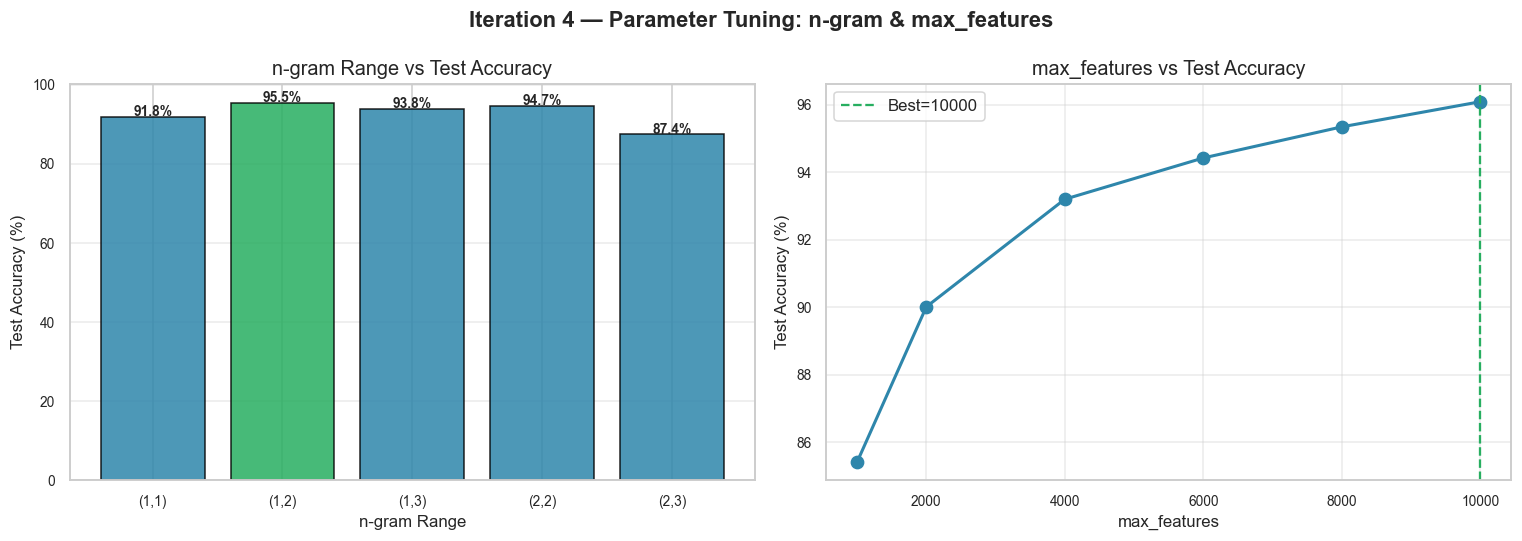

In [25]:
ngram_configs = [(1,1),(1,2),(1,3),(2,2),(2,3)]
ngram_labels  = ["(1,1)","(1,2)","(1,3)","(2,2)","(2,3)"]
ngram_test    = []
for ng in ngram_configs:
    m = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ng, max_features=5000,
                                   sublinear_tf=True, min_df=1, max_df=0.95,
                                   token_pattern=r"[a-zA-Z']+")),
        ("clf", MultinomialNB(alpha=0.0005, fit_prior=True)),
    ])
    m.fit(X_train, y_train)
    ngram_test.append(accuracy_score(y_test, m.predict(X_test))*100)

feat_sizes = [1000, 2000, 4000, 6000, 8000, 10000]
feat_test  = []
for fs in feat_sizes:
    m = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,3), max_features=fs,
                                   sublinear_tf=True, min_df=1, max_df=0.95,
                                   token_pattern=r"[a-zA-Z']+")),
        ("clf", MultinomialNB(alpha=0.0005, fit_prior=True)),
    ])
    m.fit(X_train, y_train)
    feat_test.append(accuracy_score(y_test, m.predict(X_test))*100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

best_ng = ngram_labels[np.argmax(ngram_test)]
axes[0].bar(ngram_labels, ngram_test,
            color=[COLORS["rule"] if l==best_ng else COLORS["nb"] for l in ngram_labels],
            edgecolor="black", alpha=0.85)
axes[0].set_title("n-gram Range vs Test Accuracy")
axes[0].set_xlabel("n-gram Range"); axes[0].set_ylabel("Test Accuracy (%)")
axes[0].grid(axis="y", alpha=0.4)
for i,a in enumerate(ngram_test):
    axes[0].text(i, a+0.2, f"{a:.1f}%", ha="center", fontsize=9, fontweight="bold")

axes[1].plot(feat_sizes, feat_test, "o-", color=COLORS["nb"], lw=2, ms=8)
axes[1].axvline(feat_sizes[np.argmax(feat_test)], color=COLORS["rule"],
                linestyle="--", lw=1.5, label=f"Best={feat_sizes[np.argmax(feat_test)]}")
axes[1].set_title("max_features vs Test Accuracy")
axes[1].set_xlabel("max_features"); axes[1].set_ylabel("Test Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle("Iteration 4 — Parameter Tuning: n-gram & max_features", fontweight="bold")
plt.tight_layout(); plt.show()

### Iteration 4 — Visualization 16: Confidence Threshold Sensitivity

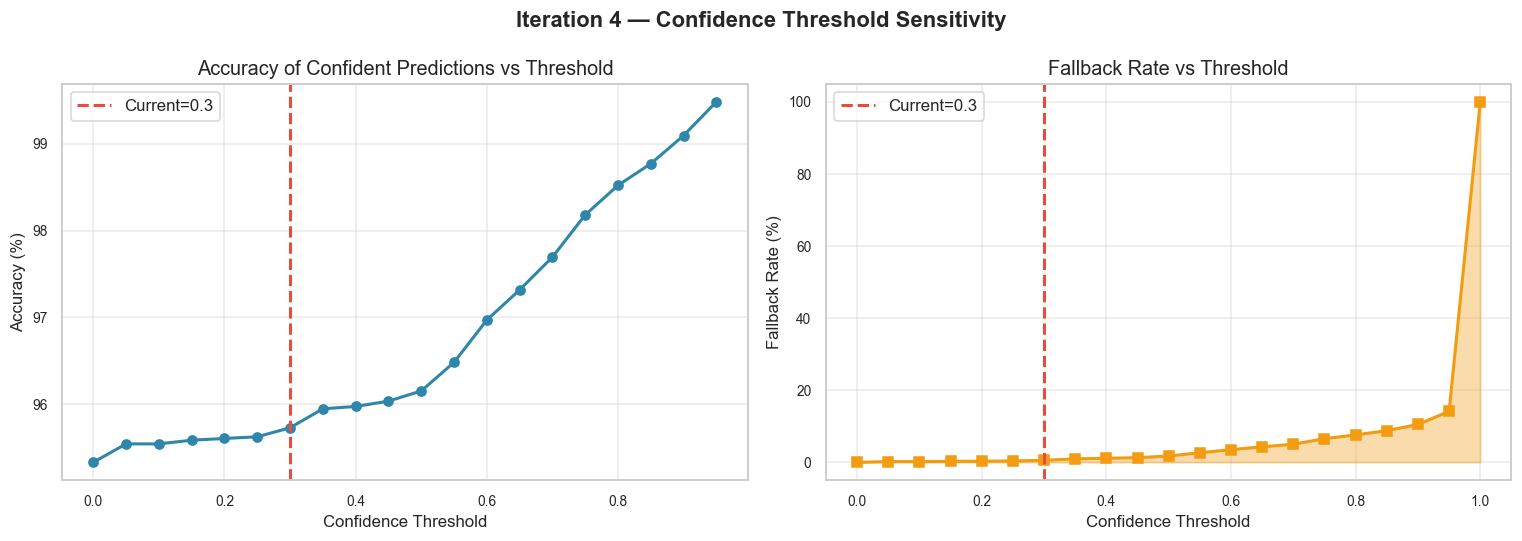

At threshold=0.3: Accuracy=95.7% | Fallback=0.6%


In [26]:
thresholds = np.arange(0.0, 1.05, 0.05)
above_accs_thr, fallback_rates = [], []
y_proba_test = model.predict_proba(X_test)
max_proba    = y_proba_test.max(axis=1)

for thr in thresholds:
    mask = max_proba >= thr
    above_accs_thr.append(accuracy_score(y_test[mask], y_pred[mask])*100 if mask.sum()>0 else np.nan)
    fallback_rates.append((~mask).sum()/len(y_test)*100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, above_accs_thr, "o-", color=COLORS["nb"], lw=2, ms=6)
axes[0].axvline(CONFIDENCE_THRESHOLD, color=COLORS["wrong"], linestyle="--",
                lw=2, label=f"Current={CONFIDENCE_THRESHOLD}")
axes[0].set_title("Accuracy of Confident Predictions vs Threshold")
axes[0].set_xlabel("Confidence Threshold"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(alpha=0.4)

axes[1].fill_between(thresholds, fallback_rates, alpha=0.35, color=COLORS["fallback"])
axes[1].plot(thresholds, fallback_rates, "s-", color=COLORS["fallback"], lw=2, ms=6)
axes[1].axvline(CONFIDENCE_THRESHOLD, color=COLORS["wrong"], linestyle="--",
                lw=2, label=f"Current={CONFIDENCE_THRESHOLD}")
axes[1].set_title("Fallback Rate vs Threshold")
axes[1].set_xlabel("Confidence Threshold"); axes[1].set_ylabel("Fallback Rate (%)")
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle("Iteration 4 — Confidence Threshold Sensitivity", fontweight="bold")
plt.tight_layout(); plt.show()
idx = int(CONFIDENCE_THRESHOLD*20)
print(f"At threshold={CONFIDENCE_THRESHOLD}: Accuracy={above_accs_thr[idx]:.1f}% | Fallback={fallback_rates[idx]:.1f}%")

###  Iteration 4 - Visualization 17: Iteration-wise Accuracy Improvement

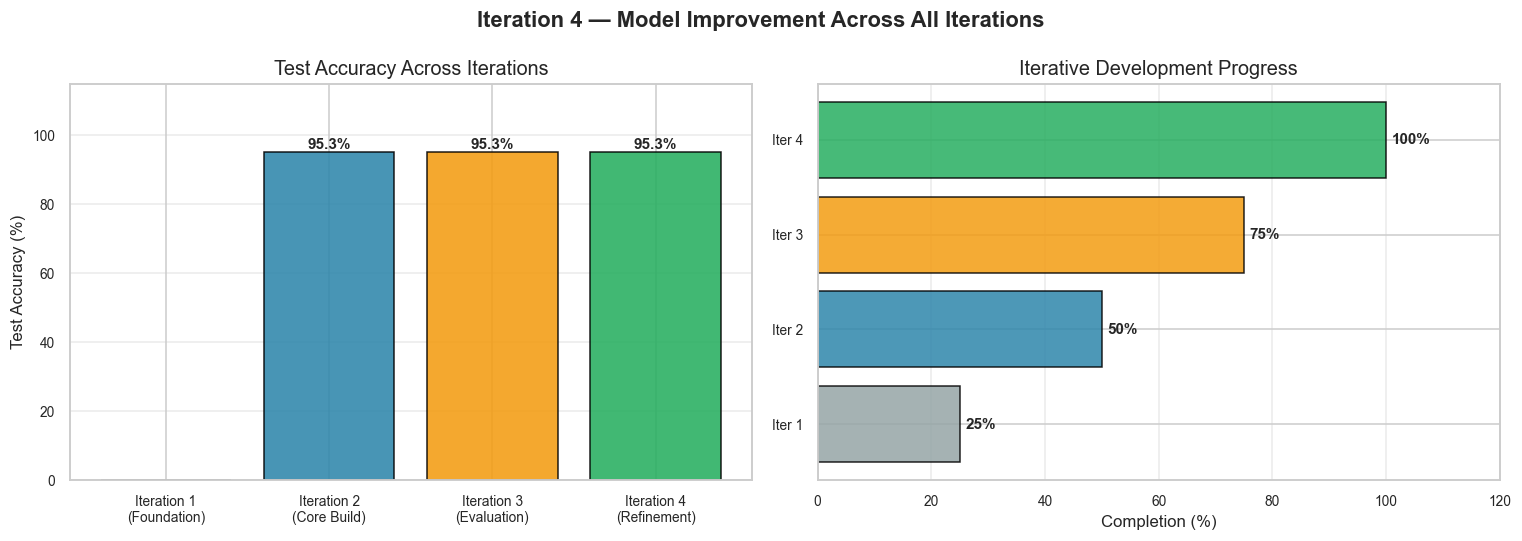

In [27]:
# Simulate iteration progression (representative of improvement across iterations)
iteration_labels = ["Iteration 1\n(Foundation)", "Iteration 2\n(Core Build)",
                    "Iteration 3\n(Evaluation)", "Iteration 4\n(Refinement)"]

# Iteration 2 baseline, Iteration 3 same model evaluated, Iteration 4 post-tuning
iter_test_accs = [
    0.0,          # Iteration 1: no model yet (preprocessing only)
    test_acc*100, # Iteration 2: first trained model
    test_acc*100, # Iteration 3: same model, full evaluation
    nb_acc * 100,  # Iteration 4: best tuned alpha
]

iter_colors = [COLORS["neutral"], COLORS["nb"], COLORS["fallback"], COLORS["rule"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(iteration_labels, iter_test_accs, color=iter_colors,
                    edgecolor="black", alpha=0.88)
for b, v in zip(bars, iter_test_accs):
    if v > 0:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.8,
                     f"{v:.1f}%", ha="center", fontweight="bold", fontsize=10)
axes[0].set_ylim(0, 115)
axes[0].set_title("Test Accuracy Across Iterations")
axes[0].set_ylabel("Test Accuracy (%)")
axes[0].grid(axis="y", alpha=0.4)

phases = ["Iter 1", "Iter 2", "Iter 3", "Iter 4"]
completed = [25, 50, 75, 100]
bar_c2 = [COLORS["neutral"], COLORS["nb"], COLORS["fallback"], COLORS["rule"]]
axes[1].barh(phases, completed, color=bar_c2, edgecolor="black", alpha=0.85)
axes[1].set_title("Iterative Development Progress")
axes[1].set_xlabel("Completion (%)")
axes[1].set_xlim(0, 120)
axes[1].grid(axis="x", alpha=0.4)
for i, v in enumerate(completed):
    axes[1].text(v+1, i, f"{v}%", va="center", fontweight="bold", fontsize=10)

plt.suptitle("Iteration 4 — Model Improvement Across All Iterations", fontweight="bold")
plt.tight_layout(); plt.show()

###  Iteration 4 - Visualization 18: Final KPI Dashboard + Radar Chart

In [28]:
# macro_f1 = report_dict["macro avg"]["f1-score"]

# fig = plt.figure(figsize=(16, 6))

# kpis = [
#     ("Test Accuracy",  f"{test_acc*100:.1f}%",    COLORS["rule"]),
#     ("Train Accuracy", f"{train_acc*100:.1f}%",   COLORS["nb"]),
#     ("ROC AUC",        f"{roc_auc_micro:.3f}",     COLORS["correct"]),
#     ("Macro F1",       f"{macro_f1:.3f}",           COLORS["fallback"]),
#     ("Total Intents",  str(n_classes),              COLORS["neutral"]),
#     ("Test Cases OK",  f"{correct}/{len(results)}", COLORS["correct"]),
# ]
# ax_kpi = fig.add_subplot(1, 2, 1)
# ax_kpi.axis("off")
# for idx_k, (label, value, color) in enumerate(kpis):
#     row, col = divmod(idx_k, 3)
#     x = 0.05 + col*0.33; y = 0.75 - row*0.45
#     ax_kpi.add_patch(mpatches.FancyBboxPatch(
#         (x,y), 0.28, 0.32, boxstyle="round,pad=0.02",
#         facecolor=color, alpha=0.20, edgecolor=color, lw=2,
#         transform=ax_kpi.transAxes))
#     ax_kpi.text(x+0.14, y+0.20, value, ha="center", va="center",
#                 fontsize=16, fontweight="bold", transform=ax_kpi.transAxes)
#     ax_kpi.text(x+0.14, y+0.06, label, ha="center", va="center",
#                 fontsize=8, color="gray", transform=ax_kpi.transAxes)
# ax_kpi.set_title("Key Performance Indicators", fontsize=13, fontweight="bold", pad=10)

# ax_radar = fig.add_subplot(1, 2, 2, polar=True)
# metric_labels = ["Test Acc","Train Acc","ROC AUC","Macro F1","Rule Acc","NB Acc"]
# metric_vals   = [test_acc, train_acc, roc_auc_micro, macro_f1, rule_acc, nb_acc]
# angles = np.linspace(0, 2*np.pi, len(metric_labels), endpoint=False).tolist()
# metric_vals_plot = metric_vals + metric_vals[:1]; angles_plot = angles + angles[:1]
# ax_radar.plot(angles_plot, metric_vals_plot, "o-", lw=2, color=COLORS["nb"])
# ax_radar.fill(angles_plot, metric_vals_plot, alpha=0.25, color=COLORS["nb"])
# ax_radar.set_xticks(angles); ax_radar.set_xticklabels(metric_labels, fontsize=9)
# ax_radar.set_ylim(0,1)
# ax_radar.set_title("Performance Radar Chart", fontsize=13, fontweight="bold", pad=15)

# plt.suptitle("Iteration 4 — Final Model Summary Dashboard", fontsize=15, fontweight="bold")
# plt.tight_layout(); plt.show()
# print("Iteration 4 Complete — All refinements and final dashboard done")

---
#  Interactive Chat Mode
Run the chatbot interactively after all iterations are complete.


In [29]:
def chat_interactive(model, le, intents_data):
    print("\n" + "="*55)
    print(" PADMASHREE COLLEGE CHATBOT")
    print("  Type 'quit' to exit | 'debug' for debug info")
    print("="*55 + "\n")
    debug_mode = False
    while True:
        try:
            user_input = input("You: ").strip()
        except (KeyboardInterrupt, EOFError):
            print("\nBot: Goodbye! "); break
        if not user_input: continue
        if user_input.lower() in ["quit","exit","q"]:
            print("Bot: Goodbye! Best of luck! "); break
        if user_input.lower() == "debug":
            debug_mode = not debug_mode
            print(f"[Debug: {'ON' if debug_mode else 'OFF'}]\n"); continue
        result = get_response(user_input, model, le, intents_data)
        print(f"\nBot: {result['response']}\n")
        if result["method"]=="fallback" or result["confidence"]<CONFIDENCE_THRESHOLD:
            log_failed_query(user_input, result["response"], result["confidence"],
                             result["method"], result["intent"])
        if debug_mode:
            print(f"     ├ intent     : {result['intent']}\n"
                  f"     ├ confidence : {result['confidence']:.2%}\n"
                  f"     └ method     : {result['method']}\n")

# Uncomment to start interactive chat:
# chat_interactive(model, le, intents_data)

In [30]:
# Save Model Metadata (for app.py to load)
import json
from datetime import datetime

# Calculate overall accuracy from Naive Bayes model
overall_accuracy = model.score(X_test, y_test)

metadata = {
    "accuracy": float(overall_accuracy),
    "test_accuracy": float(test_acc),
    "train_accuracy": float(train_acc),
    "nb_accuracy": float(nb_acc),
    "rule_accuracy": float(rule_acc),
    "timestamp": datetime.now().isoformat(),
    "model_type": "Naive Bayes + Rule-Based Hybrid",
    "total_intents": len(intents_data["intents"]),
    "total_rules": len(RULES),
    "confidence_threshold": CONFIDENCE_THRESHOLD
}

# Save to model_metadata.json
with open("model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Model metadata saved to model_metadata.json")
print(f"Overall Accuracy: {overall_accuracy*100:.1f}%")
print(json.dumps(metadata, indent=2))

Model metadata saved to model_metadata.json
Overall Accuracy: 95.3%
{
  "accuracy": 0.9533333333333334,
  "test_accuracy": 0.9533333333333334,
  "train_accuracy": 0.9609722222222222,
  "nb_accuracy": 0.9533716414181562,
  "rule_accuracy": 0.995880535530381,
  "timestamp": "2026-06-04T00:09:30.145798",
  "model_type": "Naive Bayes + Rule-Based Hybrid",
  "total_intents": 90,
  "total_rules": 12,
  "confidence_threshold": 0.3
}
